### Predictive Model for Estimating the Reach of a Training Institute on Social Media
* **Business Objective:**
The goal is to develop two predictive models that estimates the reach of a training institute’s social media campaigns.
The second Model is Regression model to predict the likes, shares and comments based on the output of classification model.
This will help in understanding how different social media activities impact the visibility and engagement of posts.

* **Client Ref:** For any Social Media Platform
* Features that can affect Reach
    - Social media info (Course Name, Day,Location etc...)
* Features that can affect Likes Shares, Comments
    - Social media info (Course Name,reach etc...)
* **Outcome:**
* The predictive models will analyze historical data from social media platforms and estimate the expected reach of future posts and the expected likes, shares and comments.
* This will allow the training institute to optimize its campaigns for better engagement and visibility

<img src="K.jpg" width=600 height=300>

### TOC <a class="anchor" id="menu"></a>


* [0. Data Collection](#dc)
* [1. Data Validation & Basic Cleaning](#dv)

    @ Insights

* [2. Data Understanding (EDA)](#eda)
* [3. Missing Values & Outliers Handling](#naout)

    @ Predictive Modeling
* [4. Predictive Modeling (Machine Learning)](#pm)
    * [4.1 X & y](#xy)
    * [4.2 Feature Engineering](#fe)
    * [4.3 Train-Test Split](#tt)
    * [4.4 Model Selection & Training](#model)
    * [4.5 & 4.6 Test Predictions & Evaluation](#eval)
    * [4.7 Selecting Better Performance Model](#best)
    * [4.8 Hypparam Tuning For Best Model(if required)](#hyp)
    * [4.9 Saving Better Performance Model](#dep)
    * [4.10 Real Time Prediction](#pred)

### 0. Data <a id=dc>
    
[Back to Top](#menu)

* **For this project , We had taken manually collected dataset**

    

In [1]:
# Base Python Libraries - Data Manipulation

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading Data using pandas methods, with variable/object name 'raw'

rawdata=pd.read_excel(r"C:\Users\USER\Desktop\SOCIAL PRACHAR\internship\PREDICITVE MODELING TASK\smfinal.xlsx")

In [3]:
rawdata

,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Date,Location,Reach
0,Quality Thought,AI,insta,10700,post,5,0,0.0,2025-02-01 00:00:00,Hyderabad,High
1,Quality Thought,AI,insta,10700,post,5,4,0.0,2025-01-31 00:00:00,Hyderabad,Moderate
2,Quality Thought,AI,insta,10700,post,11,5,3.0,2025-01-30 00:00:00,Hyderabad,Low
3,Quality Thought,AI,insta,NaN,post,6,0,4.0,29-01-200,Hyderabad,Moderate
4,"""@###""",AI,insta,10700,post,14,0,0.0,2025-01-28 00:00:00,Hyderabad,Low
...,...,...,...,...,...,...,...,...,...,...,...
616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hyderabad,Low
617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hyderabad,Low
618,Srish Technology,AW%%,NaN,114,eeio,2,0,0.0,NaN,Hyderabad,Low
619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### column info:

| Column Name         | Description |
|---------------------|-------------|
| **Institute Name**  | Name of the institution offering the course. |
| **CourseName**      | Name of the course being analyzed. |
| **Platform**       | The platform where the course is being promoted (e.g., social media, websites). |
| **Followers**       | The number of followers of the institution or course page. |
| **type**           | The type/category of the course or post. |
| **Likes**          | Number of likes received on the post. |
| **Comments**       | Number of comments on the post. |
| **Share**          | Number of times the post was shared. |
| **Date**           | The date when the post was made. |
| **Location**       | The location associated with the institute or course. |
| **Interaction score** | A calculated score based on user interactions (likes, comments, shares, etc.). |
| **Reach**          | Taken this column based on number of follwers,type of post,number of shares. |

* **Basic Checks of Dataset**

In [4]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Institute Name  589 non-null    object 
 1   CourseName      569 non-null    object 
 2   Platform        607 non-null    object 
 3   Followers       595 non-null    object 
 4   type            595 non-null    object 
 5   Likes           604 non-null    object 
 6   Comments        607 non-null    object 
 7   Share           610 non-null    float64
 8   Date            594 non-null    object 
 9   Location        619 non-null    object 
 10  Reach           317 non-null    object 
dtypes: float64(1), object(10)
memory usage: 53.5+ KB


In [5]:
print("First five rows of Dataset:")
display(rawdata.head())

print("Last five rows of Dataset:")
rawdata.tail()

First five rows of Dataset:


,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Date,Location,Reach
0,Quality Thought,AI,insta,10700,post,5,0,0.0,2025-02-01 00:00:00,Hyderabad,High
1,Quality Thought,AI,insta,10700,post,5,4,0.0,2025-01-31 00:00:00,Hyderabad,Moderate
2,Quality Thought,AI,insta,10700,post,11,5,3.0,2025-01-30 00:00:00,Hyderabad,Low
3,Quality Thought,AI,insta,NaN,post,6,0,4.0,29-01-200,Hyderabad,Moderate
4,"""@###""",AI,insta,10700,post,14,0,0.0,2025-01-28 00:00:00,Hyderabad,Low


Last five rows of Dataset:


,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Date,Location,Reach
616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hyderabad,Low
617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hyderabad,Low
618,Srish Technology,AW%%,NaN,114,eeio,2,0,0.0,NaN,Hyderabad,Low
619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Column data Check (Null Values & Data Types):")
print()
rawdata.info()

Column data Check (Null Values & Data Types):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Institute Name  589 non-null    object 
 1   CourseName      569 non-null    object 
 2   Platform        607 non-null    object 
 3   Followers       595 non-null    object 
 4   type            595 non-null    object 
 5   Likes           604 non-null    object 
 6   Comments        607 non-null    object 
 7   Share           610 non-null    float64
 8   Date            594 non-null    object 
 9   Location        619 non-null    object 
 10  Reach           317 non-null    object 
dtypes: float64(1), object(10)
memory usage: 53.5+ KB


### 1. Data Validation & Cleaning <a id=dv>
   
[Back to Top](#menu)

In [7]:
# Taking copy of data
raw = rawdata.copy()

* **Validating Each Column Data**

In [8]:
raw.columns

Index(['Institute Name', 'CourseName', 'Platform', 'Followers', 'type',
       'Likes', 'Comments', 'Share ', 'Date', 'Location', 'Reach'],
      dtype='object')

In [9]:
def colcheck(df , col):
    print("column: ", col)
    print()
    print(f"Number Of Unique Values In Column:{df[col].nunique()}")
    print()
    print("unique values in column:")
    print()
    print(df[col].unique())
    print()
    print("data type of column:" , df[col].dtype)
    print()

                                        Institute Name

In [10]:
colcheck(raw,'Institute Name')

column:  Institute Name

Number Of Unique Values In Column:36

unique values in column:

['Quality Thought' '"@###"' nan 'institute@@' 'nameof' 'Naaa'
 'Naresh i Technologies' 'Nhu' 'Innomatics Research Labs' ' Labsji'
 'FullStackAcademy' 'new' 'insti' 'F#re' 'Institutename' 'TeksAcademy'
 'Datamites' 'Datafs' 'Cedlearn' 'Elearn Infotech'
 'Nxtwave Disruptive Technologies' 'ExcelR' 'Social Prachar '
 'Besant Technologies' 'FITA Academy' 'Mindmajix' 'Brolly Academy'
 'PRSoftwares' 'Harsha Trainings' 'TeksAcademy '
 'Vcube Software Solutions' 'Vcube )8*6' 'Version iT' 'Version iTt6yghb&&'
 'Version iT***' 'Saidemy' 'Srish Technology']

data type of column: object



In [11]:
raw['Institute Name'].replace('"@###"',np.nan,inplace=True)
raw['Institute Name'].replace('institute@@',np.nan,inplace=True)
raw['Institute Name'].replace('nameof',np.nan,inplace=True)
raw['Institute Name'].replace('Naaa',np.nan,inplace=True)
raw['Institute Name'].replace('Nhu',np.nan,inplace=True)
raw['Institute Name'].replace(' Labsji',np.nan,inplace=True)
raw['Institute Name'].replace('new',np.nan,inplace=True)
raw['Institute Name'].replace('insti',np.nan,inplace=True)
raw['Institute Name'].replace('F#re',np.nan,inplace=True)
raw['Institute Name'].replace('Institutename',np.nan,inplace=True)
raw['Institute Name'].replace('Datafs',np.nan,inplace=True)
raw['Institute Name'].replace('Vcube )8*6','Vcube Software Solutions',inplace=True)
raw['Institute Name'].replace('Version iTt6yghb&&','Version iT',inplace=True)
raw['Institute Name'].replace('Version iT***','Version iT',inplace=True)



In [12]:
colcheck(raw,'Institute Name')

column:  Institute Name

Number Of Unique Values In Column:22

unique values in column:

['Quality Thought' nan 'Naresh i Technologies' 'Innomatics Research Labs'
 'FullStackAcademy' 'TeksAcademy' 'Datamites' 'Cedlearn' 'Elearn Infotech'
 'Nxtwave Disruptive Technologies' 'ExcelR' 'Social Prachar '
 'Besant Technologies' 'FITA Academy' 'Mindmajix' 'Brolly Academy'
 'PRSoftwares' 'Harsha Trainings' 'TeksAcademy '
 'Vcube Software Solutions' 'Version iT' 'Saidemy' 'Srish Technology']

data type of column: object



In [13]:
raw['Institute Name']=raw['Institute Name'].str.strip(" ")

                                        Course name

In [14]:
colcheck(raw,'CourseName')

column:  CourseName

Number Of Unique Values In Column:22

unique values in column:

['AI' 'Data Analytics' 'Dats' 'Data Science' nan 'Dlp' 'Ds' 'Datam'
 'Dataskills' 'Dau' 'AIhy' 'Dataj' 'Full Stack Development' 'AWS,Devops'
 'Azure,Devops' 'GCP' 'AWji' 'AWSmmm' 'AWS^^' 'AW66' 'AW##' 'AW%%' 'dT']

data type of column: object



In [15]:
raw['CourseName'].replace('Dats',np.nan,inplace=True)
raw['CourseName'].replace('Dlp',np.nan,inplace=True)
raw['CourseName'].replace('Datam',np.nan,inplace=True)
raw['CourseName'].replace('Dau',np.nan,inplace=True)
raw['CourseName'].replace('AIhy',np.nan,inplace=True)
raw['CourseName'].replace('Dataj',np.nan,inplace=True)
raw['CourseName'].replace('AWji',np.nan,inplace=True)
raw['CourseName'].replace('AWSmmm',np.nan,inplace=True)
raw['CourseName'].replace('AWS^^',np.nan,inplace=True)
raw['CourseName'].replace('AW66',np.nan,inplace=True)
raw['CourseName'].replace('AW##',np.nan,inplace=True)
raw['CourseName'].replace('AW%%',np.nan,inplace=True)
raw['CourseName'].replace('dT',np.nan,inplace=True)


In [16]:
colcheck(raw,'CourseName')

column:  CourseName

Number Of Unique Values In Column:9

unique values in column:

['AI' 'Data Analytics' nan 'Data Science' 'Ds' 'Dataskills'
 'Full Stack Development' 'AWS,Devops' 'Azure,Devops' 'GCP']

data type of column: object



In [17]:
raw['CourseName']=raw['CourseName'].str.strip(" ")

                                            Platform

In [18]:
colcheck(raw,'Platform')

column:  Platform

Number Of Unique Values In Column:11

unique values in column:

['insta' nan 'rt' 'i' 'instagy' 'Insta' 'In' 'insta^^' 'kol' 'instl'
 'insoooa' 'profile']

data type of column: object



In [19]:
raw['Platform'].replace('rt',np.nan,inplace=True)
raw['Platform'].replace('i',np.nan,inplace=True)
raw['Platform'].replace('instagy',np.nan,inplace=True)
raw['Platform'].replace('In',np.nan,inplace=True)
raw['Platform'].replace('insta^^',np.nan,inplace=True)
raw['Platform'].replace('kol',np.nan,inplace=True)
raw['Platform'].replace('instl',np.nan,inplace=True)
raw['Platform'].replace('insoooa',np.nan,inplace=True)
raw['Platform'].replace('profile',np.nan,inplace=True)

In [20]:
raw['Platform']=raw['Platform'].str.strip(' ')
raw['Platform'].replace('insta','Insta',inplace=True)

In [21]:
colcheck(raw,'Platform')

column:  Platform

Number Of Unique Values In Column:1

unique values in column:

['Insta' nan]

data type of column: object



                                                    Followers

In [22]:
colcheck(raw,'Followers')

column:  Followers

Number Of Unique Values In Column:30

unique values in column:

[10700 nan '12ed' '4#$' 54300 '543op' 11100 6459 '64%%' 9038 12200 5618
 '561--' 746 '111&' 54368 200978 10226 15250 82672 18338 2785 411 3391
 '33p1' 7308 41200 129 9142 6406 114]

data type of column: object



In [23]:
raw['Followers'].replace('4#$',4,inplace=True)
raw['Followers'].replace('12ed',12,inplace=True)
raw['Followers'].replace('543op',543,inplace=True)
raw['Followers'].replace('64%%',64,inplace=True)
raw['Followers'].replace('561--',561,inplace=True)
raw['Followers'].replace('111&',111,inplace=True)
raw['Followers'].replace('33p1',33,inplace=True)

In [24]:
colcheck(raw,'Followers')

column:  Followers

Number Of Unique Values In Column:30

unique values in column:

[1.07000e+04         nan 1.20000e+01 4.00000e+00 5.43000e+04 5.43000e+02
 1.11000e+04 6.45900e+03 6.40000e+01 9.03800e+03 1.22000e+04 5.61800e+03
 5.61000e+02 7.46000e+02 1.11000e+02 5.43680e+04 2.00978e+05 1.02260e+04
 1.52500e+04 8.26720e+04 1.83380e+04 2.78500e+03 4.11000e+02 3.39100e+03
 3.30000e+01 7.30800e+03 4.12000e+04 1.29000e+02 9.14200e+03 6.40600e+03
 1.14000e+02]

data type of column: float64



                                            Type

In [25]:
colcheck(raw,'type')

column:  type

Number Of Unique Values In Column:10

unique values in column:

['post' nan 'reel' 'po&&' 'rll' 'POST' 'REEL' 'RE%%' 'Post' 'POSi' 'eeio']

data type of column: object



In [26]:
raw['type'].replace('po&&',np.nan,inplace=True)
raw['type'].replace('rll',np.nan,inplace=True)
raw['type'].replace('RE%%',np.nan,inplace=True)
raw['type'].replace('POSi',np.nan,inplace=True)
raw['type'].replace('eeio',np.nan,inplace=True)

In [27]:
colcheck(raw,'type')

column:  type

Number Of Unique Values In Column:5

unique values in column:

['post' nan 'reel' 'POST' 'REEL' 'Post']

data type of column: object



In [28]:
  raw.columns                                                          

Index(['Institute Name', 'CourseName', 'Platform', 'Followers', 'type',
       'Likes', 'Comments', 'Share ', 'Date', 'Location', 'Reach'],
      dtype='object')

                                                Likes

In [29]:
colcheck(raw,'Likes')

column:  Likes

Number Of Unique Values In Column:158

unique values in column:

[5 11 6 14 9 7 nan 21 8 13 80 15 12 27 44 25 119 34 30 39 59 109 89 40 69
 28 24 60 26 31 62 212 41 128 29 357 910 176 167 55 74 45 20 35 22 37 47
 36 17 53 46 350 51 19 93 73 77 23 129 3 142 137 32 33 54 18 75 65 68 10
 42 52 38 56 4 2 1 16 66 95 323 540 373 359 356 422 304 959 583 857 380
 382 124 67 63 48 58 1317 134 49 57 91 84 94 132 92 76 43 '48lp' 50 61 64
 70 71 72 78 79 81 82 83 85 86 87 88 90 96 97 98 99 100 101 102 103 104
 105 106 107 108 110 111 112 113 114 115 116 117 118 120 121 122 123 125
 126 127 130 131 133 135 136]

data type of column: object



In [30]:
raw['Likes'].replace('48lp',np.nan,inplace=True)

In [31]:
colcheck(raw,'Likes')

column:  Likes

Number Of Unique Values In Column:157

unique values in column:

[5.000e+00 1.100e+01 6.000e+00 1.400e+01 9.000e+00 7.000e+00       nan
 2.100e+01 8.000e+00 1.300e+01 8.000e+01 1.500e+01 1.200e+01 2.700e+01
 4.400e+01 2.500e+01 1.190e+02 3.400e+01 3.000e+01 3.900e+01 5.900e+01
 1.090e+02 8.900e+01 4.000e+01 6.900e+01 2.800e+01 2.400e+01 6.000e+01
 2.600e+01 3.100e+01 6.200e+01 2.120e+02 4.100e+01 1.280e+02 2.900e+01
 3.570e+02 9.100e+02 1.760e+02 1.670e+02 5.500e+01 7.400e+01 4.500e+01
 2.000e+01 3.500e+01 2.200e+01 3.700e+01 4.700e+01 3.600e+01 1.700e+01
 5.300e+01 4.600e+01 3.500e+02 5.100e+01 1.900e+01 9.300e+01 7.300e+01
 7.700e+01 2.300e+01 1.290e+02 3.000e+00 1.420e+02 1.370e+02 3.200e+01
 3.300e+01 5.400e+01 1.800e+01 7.500e+01 6.500e+01 6.800e+01 1.000e+01
 4.200e+01 5.200e+01 3.800e+01 5.600e+01 4.000e+00 2.000e+00 1.000e+00
 1.600e+01 6.600e+01 9.500e+01 3.230e+02 5.400e+02 3.730e+02 3.590e+02
 3.560e+02 4.220e+02 3.040e+02 9.590e+02 5.830e+02 8.570e+02 3.800e

                                        Comments

In [32]:
colcheck(raw,'Comments')

column:  Comments

Number Of Unique Values In Column:16

unique values in column:

[0 4 5 2 nan 12 1 42 7 8 15 10 3 13 6 9 '0j']

data type of column: object



In [33]:
raw['Comments'].replace('0j',np.nan,inplace=True)

In [34]:
colcheck(raw,'Comments')

column:  Comments

Number Of Unique Values In Column:15

unique values in column:

[ 0.  4.  5.  2. nan 12.  1. 42.  7.  8. 15. 10.  3. 13.  6.  9.]

data type of column: float64



                                                    Shares

In [35]:
raw.columns=raw.columns.str.strip(" ")

In [36]:
raw.columns

Index(['Institute Name', 'CourseName', 'Platform', 'Followers', 'type',
       'Likes', 'Comments', 'Share', 'Date', 'Location', 'Reach'],
      dtype='object')

In [37]:
colcheck(raw,'Share')

column:  Share

Number Of Unique Values In Column:29

unique values in column:

[  0.   3.   4.   1.   2.   9.   5.  24.  12.  11.  13.  23.   6.   7.
  40. 125.  22.  17.   8.  38.  10.  28. 205.  27.  15.  16.  21.  26.
  18.  nan]

data type of column: float64



                                        Date

In [38]:
colcheck(raw,'Date')

column:  Date

Number Of Unique Values In Column:251

unique values in column:

[datetime.datetime(2025, 2, 1, 0, 0) datetime.datetime(2025, 1, 31, 0, 0)
 datetime.datetime(2025, 1, 30, 0, 0) '29-01-200'
 datetime.datetime(2025, 1, 28, 0, 0) datetime.datetime(2025, 1, 25, 0, 0)
 nan datetime.datetime(2024, 12, 26, 0, 0)
 datetime.datetime(2024, 12, 24, 0, 0) '04-01---'
 datetime.datetime(2024, 12, 20, 0, 0)
 datetime.datetime(2024, 12, 18, 0, 0) '18-12-=' '10&&&'
 datetime.datetime(2024, 12, 10, 0, 0)
 datetime.datetime(2024, 11, 22, 0, 0)
 datetime.datetime(2024, 11, 19, 0, 0)
 datetime.datetime(2024, 11, 13, 0, 0)
 datetime.datetime(2024, 11, 12, 0, 0)
 datetime.datetime(2024, 11, 11, 0, 0)
 datetime.datetime(2024, 10, 22, 0, 0)
 datetime.datetime(2024, 10, 14, 0, 0)
 datetime.datetime(2024, 10, 11, 0, 0)
 datetime.datetime(2024, 9, 30, 0, 0) datetime.datetime(2024, 9, 22, 0, 0)
 datetime.datetime(2025, 2, 6, 0, 0) datetime.datetime(2025, 2, 4, 0, 0)
 datetime.datetime(2025, 1, 18, 0

In [39]:
raw['Date'].replace('29-01-200',np.nan,inplace=True)
raw['Date'].replace('04-01---',np.nan,inplace=True)
raw['Date'].replace('18-12-=',np.nan,inplace=True)
raw['Date'].replace('10&&&',np.nan,inplace=True)
raw['Date'].replace('09-10op',np.nan,inplace=True)
raw['Date'].replace('07-02-20ui',np.nan,inplace=True)
raw['Date'].replace('04-01-2tgn',np.nan,inplace=True)
raw['Date'].replace('28*88',np.nan,inplace=True)
raw['Date'].replace('31-01-202509',np.nan,inplace=True)
raw['Date'].replace('&&',np.nan,inplace=True)
raw['Date'].replace('10-09-2((',np.nan,inplace=True)
raw['Date'].replace('28/10/20==',np.nan,inplace=True)
raw['Date'].replace('22/1ll',np.nan,inplace=True)
raw['Date'].replace('25/100024',np.nan,inplace=True)

In [40]:
raw['Day']=pd.to_datetime(raw['Date']).dt.day_name()

In [41]:
del raw['Date']

In [42]:
                                                raw.columns

Index(['Institute Name', 'CourseName', 'Platform', 'Followers', 'type',
       'Likes', 'Comments', 'Share', 'Location', 'Reach', 'Day'],
      dtype='object')

                                                    Location

In [43]:
colcheck(raw,'Location')

column:  Location

Number Of Unique Values In Column:2

unique values in column:

['Hyderabad' 'Banglore' nan]

data type of column: object



                                                Reach

In [44]:
colcheck(raw,'Reach')

column:  Reach

Number Of Unique Values In Column:3

unique values in column:

['High' 'Moderate' 'Low' nan]

data type of column: object



In [45]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621 entries, 0 to 620
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Institute Name  578 non-null    object 
 1   CourseName      555 non-null    object 
 2   Platform        598 non-null    object 
 3   Followers       595 non-null    float64
 4   type            589 non-null    object 
 5   Likes           603 non-null    float64
 6   Comments        606 non-null    float64
 7   Share           610 non-null    float64
 8   Location        619 non-null    object 
 9   Reach           317 non-null    object 
 10  Day             580 non-null    object 
dtypes: float64(4), object(7)
memory usage: 53.5+ KB


* All columns data is valid and data types are also proper

In [46]:
raw.head(2)

,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Location,Reach,Day
0,Quality Thought,AI,Insta,10700.0,post,5.0,0.0,0.0,Hyderabad,High,Saturday
1,Quality Thought,AI,Insta,10700.0,post,5.0,4.0,0.0,Hyderabad,Moderate,Friday


In [47]:
raw.shape

(621, 11)

In [48]:
for col in raw.columns:
    if raw[col].dtype==object:
        raw[col] = raw[col].str.lower()

In [49]:
raw[raw.duplicated()]

,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Location,Reach,Day
217,elearn infotech,full stack development,insta,746.0,post,3.0,0.0,1.0,hyderabad,NaN,saturday
219,elearn infotech,full stack development,insta,746.0,post,3.0,0.0,0.0,hyderabad,NaN,thursday
222,elearn infotech,full stack development,insta,746.0,post,3.0,0.0,0.0,hyderabad,NaN,sunday
224,elearn infotech,full stack development,insta,746.0,post,3.0,0.0,0.0,hyderabad,NaN,thursday
241,innomatics research labs,full stack development,insta,11100.0,post,16.0,0.0,0.0,hyderabad,NaN,saturday
242,innomatics research labs,full stack development,insta,11100.0,post,32.0,0.0,0.0,hyderabad,NaN,monday
252,naresh i technologies,full stack development,insta,54368.0,reel,95.0,1.0,0.0,hyderabad,low,monday
253,naresh i technologies,full stack development,insta,54368.0,post,33.0,0.0,0.0,hyderabad,low,wednesday
255,naresh i technologies,full stack development,insta,54368.0,post,45.0,0.0,0.0,hyderabad,NaN,friday
302,excelr,full stack development,insta,10226.0,post,21.0,0.0,0.0,hyderabad,NaN,tuesday


In [50]:
raw =  raw.drop_duplicates().reset_index(drop=True)

In [51]:
raw[raw.duplicated()]

,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Location,Reach,Day


In [52]:
data=raw.copy()

### 2. EDA (Data Understanding)<a id=eda>
    
[Back to Top](#menu)

* In EDA we can do Data Analysis in two methods
    - Uni-Variate Analysis (Study of Individual column Data)
        - Descriptive + Visual Analysis
    - Bi-Varaite Analysis (Study data between two columns)
        - Descriptive + Visual Analysis
    - Multi-Variate Analysis (Study data between three or more columns)
        - Descriptive Stats

### 2.1 Uni-Variate Analysis

In [53]:
# Viz Libraries

import matplotlib.pyplot as plt
import seaborn as sns

from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

* Taking user-defined module eda

In [54]:
def descriptive_stats(df):
    # Selecting only numerical columns
    numeric_cols = df.select_dtypes(include=['number'])

    # Numerical Columns Summary
    print("Statistical Summary of Numerical Columns:\n")
    numerical_summary = numeric_cols.describe().T  # Transpose for better readability

    # Compute Mean, Median, and Mode for numerical columns safely
    numerical_summary['mean'] = numeric_cols.mean()
    numerical_summary['median'] = numeric_cols.median()

    # Handling mode safely (some columns may have multiple mode values)
    mode_values = numeric_cols.mode().iloc[0] if not numeric_cols.mode().empty else None
    numerical_summary['mode'] = mode_values

    print(numerical_summary)

    # Categorical Columns Summary
    print("\nValue Counts and Mode for Categorical Columns:\n")
    for col in df.select_dtypes(include=['object']).columns:
        print(f"Column: {col}")
        print("Value Counts:\n", df[col].value_counts().head(10))  # Top 10 categories
        
        # Handling mode calculation for categorical columns
        mode_value = df[col].mode()
        mode_str = str(mode_value.iloc[0]) if not mode_value.empty else "No mode"
        print("Mode:", mode_str)
        print("\n")
# Example usage
descriptive_stats(data)

Statistical Summary of Numerical Columns:

           count          mean           std  min     25%      50%      75%  \
Followers  577.0  22970.005199  38844.425972  4.0  5618.0  10226.0  18338.0   
Likes      585.0     52.415385    102.446762  1.0    11.0     29.0     57.0   
Comments   588.0      0.399660      2.200774  0.0     0.0      0.0      0.0   
Share      592.0      2.684122     10.839541  0.0     0.0      0.0      2.0   

                max   median     mode  
Followers  200978.0  10226.0  11100.0  
Likes        1317.0     29.0      2.0  
Comments       42.0      0.0      0.0  
Share         205.0      0.0      0.0  

Value Counts and Mode for Categorical Columns:

Column: Institute Name
Value Counts:
 Institute Name
naresh i technologies       76
teksacademy                 70
innomatics research labs    48
datamites                   41
version it                  37
quality thought             33
excelr                      27
prsoftwares                 25
srish techn

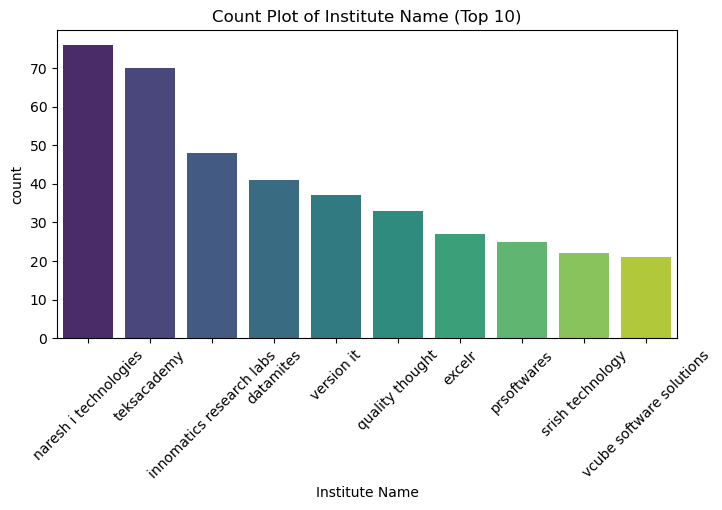

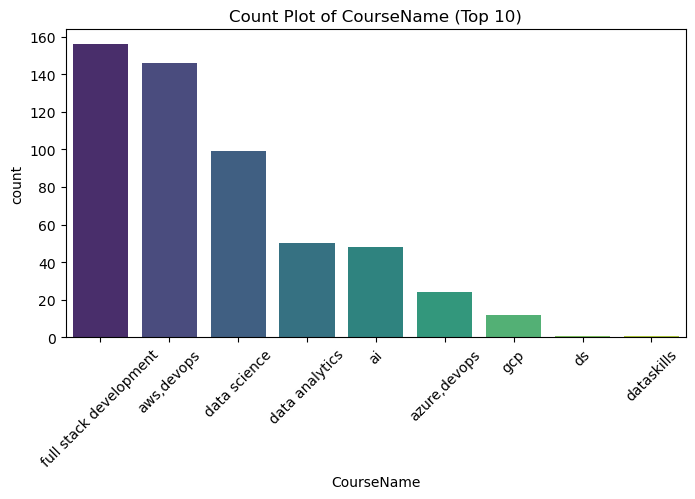

<Figure size 800x400 with 0 Axes>

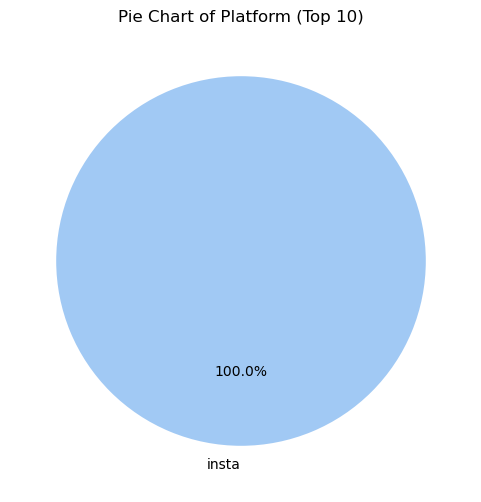

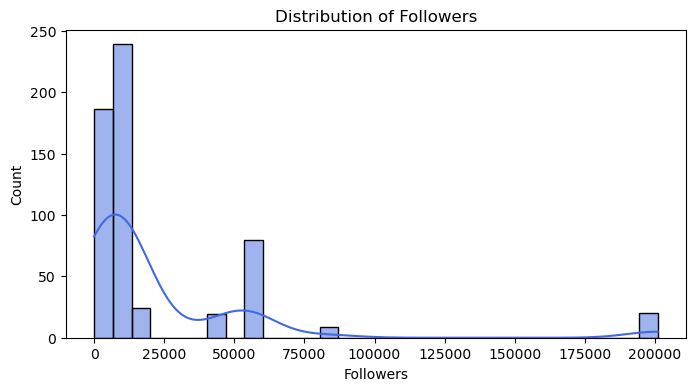

<Figure size 800x400 with 0 Axes>

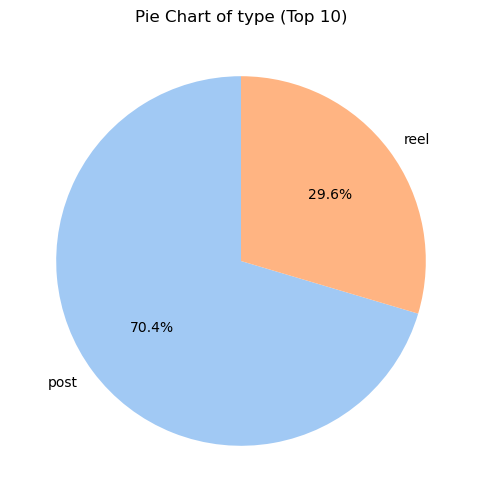

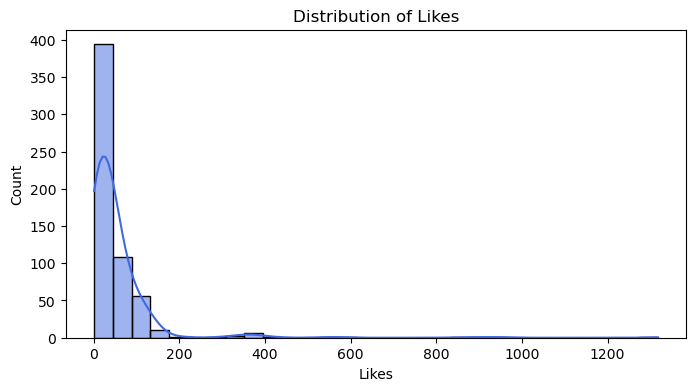

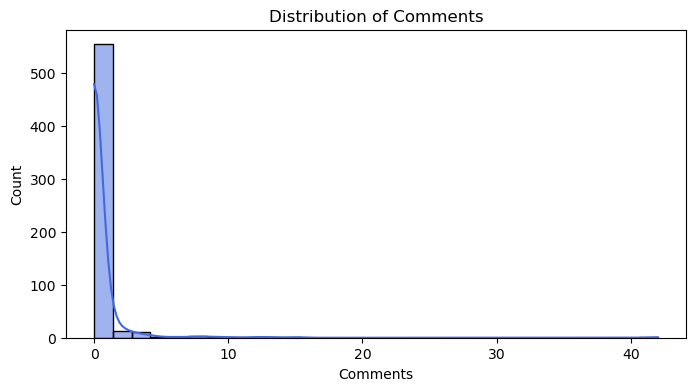

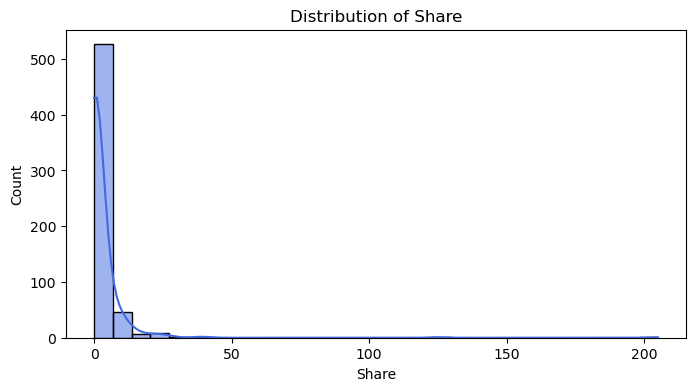

<Figure size 800x400 with 0 Axes>

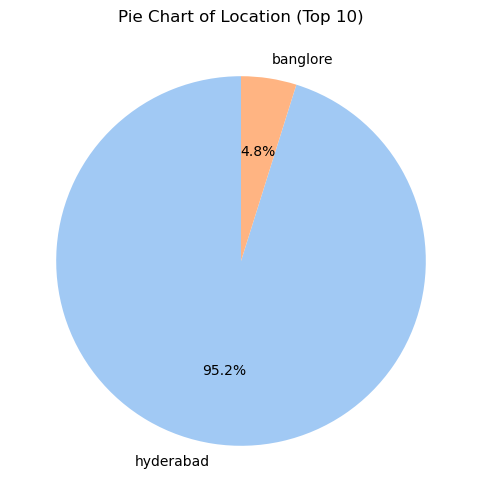

<Figure size 800x400 with 0 Axes>

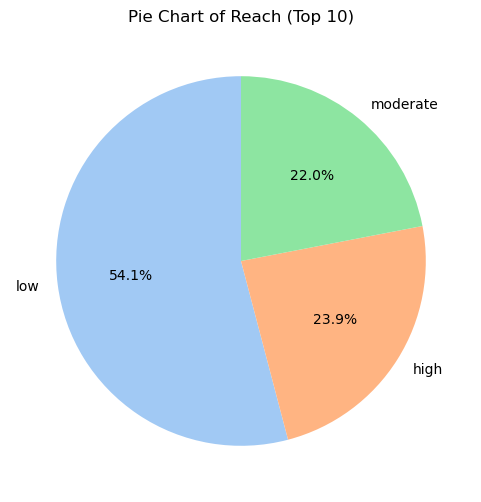

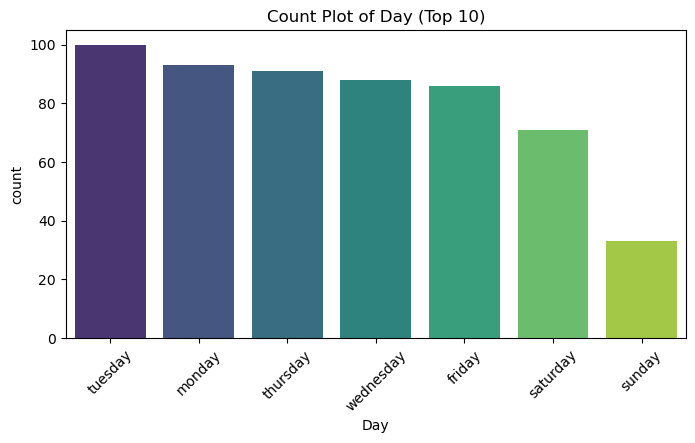

In [55]:
def univariate_analysis(df):
    for col in df.columns:
        plt.figure(figsize=(8, 4))
        
        if df[col].dtype == 'object':  # Categorical columns
            value_counts = df[col].value_counts().nlargest(10)  # Get top 10 categories
            
            if len(value_counts) <= 5:  # Use pie chart if ≤5 categories
                plt.figure(figsize=(6, 6))
                value_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
                plt.title(f'Pie Chart of {col} (Top 10)')
                plt.ylabel('')
            else:  # Use count plot for more than 5 categories
                sns.countplot(x=df[col], order=value_counts.index, palette='viridis')
                plt.xticks(rotation=45)
                plt.title(f'Count Plot of {col} (Top 10)')
            
            plt.show()
        
        else:  # Numerical columns
            sns.histplot(df[col], kde=True, bins=30, color='royalblue')
            plt.title(f'Distribution of {col}')
            plt.show()
univariate_analysis(data)

**Uni-Variate Insights**
* There are 21 institutes data in the datset and more posts of naresh i techologies.
* There are 9 different course posts or reels in data and more posts or reels on full stack development course.
* Data is collected from instagram
* Average follwers are 23126.
* Most of the content is uploaded as post in social media.
* Average likes are 52
* There are minmum 0 and maximum 42 comments according to  data.
* Average shares are 2 according to data.
* Most of institutes data is from hyderabad.
* Low reach is higher in count than other.
* There are more number of posts or reels posted on tuesday.

**2.2 Bi/Multi-Variate Analysis**
- Descriptive Stats Measures used to study data between two or more columns.

**Bi/Multi-Variate Combo**|**Stats Measures**
----|-----------
**Numeric-Numeric-..**|**Correlation (-1 to +1)**
**Numeric-Categorical-..**|**Aggregation Functions (count, min, max, avg, sum)**
**Categorical-Categorical-...**|**FDT**

In [56]:
data.head(2)

,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Location,Reach,Day
0,quality thought,ai,insta,10700.0,post,5.0,0.0,0.0,hyderabad,high,saturday
1,quality thought,ai,insta,10700.0,post,5.0,4.0,0.0,hyderabad,moderate,friday


                                                      Pure numeric
                                        
- To understand the data between number columns we can use correlation coeficient measure from descriptive stats

In [57]:
# Considering followers and likes

round(data[['Followers','Likes']].corr(),2)

,Followers,Likes
Followers,1.00,0.44
Likes,0.44,1.00


In [58]:
plt.figure(figsize=(4, 3))
px.scatter(data, x='Followers', y='Likes', trendline='ols', trendline_color_override='black', width=600, height=350)

# data between two columns was shown in points in x & y axes

<Figure size 400x300 with 0 Axes>

Insights:
* The data shows there is a weak positive correlation between Followers and Likes

In [59]:
# Considering followers and likes

round(data[['Share','Likes']].corr(),2)

,Share,Likes
Share,1.00,0.24
Likes,0.24,1.00


In [60]:
plt.figure(figsize=(4, 3))
px.scatter(data, x='Likes', y='Share', trendline='ols', trendline_color_override='black', width=600, height=350)

# data between two columns was shown in points in x & y axes

<Figure size 400x300 with 0 Axes>

Insights:
* The data shows that there is weak positive correlation between Likes and Shares

                                                         Pure categorical

In [61]:
###### Checking Categorical Columns

data.select_dtypes("O")

,Institute Name,CourseName,Platform,type,Location,Reach,Day
0,quality thought,ai,insta,post,hyderabad,high,saturday
1,quality thought,ai,insta,post,hyderabad,moderate,friday
2,quality thought,ai,insta,post,hyderabad,low,thursday
3,quality thought,ai,insta,post,hyderabad,moderate,NaN
4,NaN,ai,insta,post,hyderabad,low,tuesday
...,...,...,...,...,...,...,...
595,social prachar,NaN,NaN,NaN,hyderabad,NaN,NaN
596,NaN,NaN,insta,NaN,hyderabad,low,NaN
597,srish technology,NaN,insta,NaN,hyderabad,low,NaN
598,srish technology,NaN,NaN,NaN,hyderabad,low,NaN


In [62]:
# Using pandas df crosstab to get FDT between two columns
pd.crosstab(data['Institute Name'], data['Reach'], margins=True)

Reach,high,low,moderate,All
Institute Name,,,,
besant technologies,2,6,0,8
brolly academy,1,7,1,9
cedlearn,3,1,3,7
datamites,2,5,1,8
elearn infotech,0,3,1,4
excelr,4,11,2,17
fita academy,4,3,0,7
fullstackacademy,0,1,2,3
harsha trainings,2,1,2,5


In [63]:
px.bar(data,x='Institute Name',y='Reach')

Insights:
* More posts or reels have low reach.

In [64]:
# We can use crosstab function in pandas to get FDT (Frequency Distribution Table) of each class

print("CourseName vs Type:")

display(pd.crosstab(data['CourseName'], data['type'], margins=True))

CourseName vs Type:


type,post,reel,All
CourseName,,,
ai,30,16,46
"aws,devops",113,29,142
"azure,devops",18,6,24
data analytics,37,12,49
data science,58,40,98
dataskills,1,0,1
full stack development,102,48,150
gcp,12,0,12
All,371,151,522


Insights:
* There are more number of posts than reels

                                                             Mixed

In [65]:
# Taking pandas df groupby to get aggregations between above columns
round(data.groupby('Institute Name')['Likes'].sum().sort_values(ascending=False),2) # Considering sum

Institute Name
nxtwave disruptive technologies    6083.0
naresh i technologies              4820.0
teksacademy                        4449.0
srish technology                   2284.0
fita academy                       1972.0
version it                         1871.0
innomatics research labs           1383.0
vcube software solutions           1248.0
datamites                          1184.0
fullstackacademy                   1051.0
saidemy                            1007.0
excelr                              663.0
quality thought                     325.0
cedlearn                            277.0
besant technologies                 171.0
harsha trainings                    134.0
mindmajix                            97.0
brolly academy                       57.0
social prachar                       53.0
elearn infotech                      44.0
prsoftwares                          39.0
Name: Likes, dtype: float64

In [66]:
px.box(data, x="Institute Name", y="Likes")

Insights:
* Nxtwave disruptive technologies posts or reels have more number of likes

In [67]:
# Taking pandas df groupby to get aggregations between above columns
round(data.groupby('CourseName')['Likes'].sum().sort_values(ascending=False),2) # Considering sum 

CourseName
aws,devops                9514.0
full stack development    8736.0
data science              4580.0
data analytics            2261.0
ai                        1112.0
azure,devops               732.0
gcp                        202.0
dataskills                 129.0
ds                           9.0
Name: Likes, dtype: float64

In [68]:
px.box(data, x="CourseName", y="Likes")

* AWS,Devops course has more number of likes

In [69]:
data.columns

Index(['Institute Name', 'CourseName', 'Platform', 'Followers', 'type',
       'Likes', 'Comments', 'Share', 'Location', 'Reach', 'Day'],
      dtype='object')

In [70]:
# More than two columns

data[['Institute Name','CourseName','Likes','Share']]

,Institute Name,CourseName,Likes,Share
0,quality thought,ai,5.0,0.0
1,quality thought,ai,5.0,0.0
2,quality thought,ai,11.0,3.0
3,quality thought,ai,6.0,4.0
4,NaN,ai,14.0,0.0
...,...,...,...,...
595,social prachar,NaN,NaN,NaN
596,NaN,NaN,NaN,NaN
597,srish technology,NaN,NaN,NaN
598,srish technology,NaN,2.0,0.0


In [71]:
round(data.groupby(['Institute Name','CourseName'])[['Likes', 'Share']].sum())

Likes  Share
Institute Name                  CourseName                           
besant technologies             full stack development   139.0    0.0
brolly academy                  full stack development    41.0    0.0
cedlearn                        ai                        42.0   10.0
                                aws,devops                56.0    1.0
                                data analytics            95.0    2.0
                                data science              33.0    1.0
datamites                       ai                       225.0   15.0
                                data analytics           283.0   21.0
                                data science             676.0   40.0
elearn infotech                 full stack development    33.0    8.0
excelr                          full stack development   653.0    0.0
fita academy                    full stack development   653.0    0.0
fullstackacademy                ai                       288.0   28.0
                                data analytics           591.0   65.0
                                data science             172.0   57.0
harsha trainings                aws,devops                56.0   16.0
                                azure,devops              50.0    7.0
                                gcp                       28.0    4.0
innomatics research labs        ai                       154.0   32.0
                                data analytics           202.0    4.0
                                data science             664.0   50.0
                                full stack development   336.0    0.0
mindmajix                       full stack development    84.0    0.0
naresh i technologies           ai                       181.0   16.0
                                aws,devops               691.0   99.0
                                azure,devops             238.0   19.0
                                data analytics           762.0  124.0
                                data science            1964.0  243.0
                                full stack development   563.0    7.0
                                gcp                       78.0   12.0
nxtwave disruptive technologies full stack development  6060.0    2.0
prsoftwares                     full stack development    32.0    0.0
quality thought                 ai                        70.0    8.0
                                aws,devops                19.0    1.0
                                azure,devops              17.0    1.0
                                data analytics            19.0    0.0
                                data science             139.0    6.0
                                ds                         9.0    0.0
                                gcp                       19.0    0.0
saidemy                         aws,devops               782.0    0.0
social prachar                  full stack development    53.0    0.0
srish technology                aws,devops              1642.0    0.0
teksacademy                     ai                        68.0    6.0
                                aws,devops              3426.0   38.0
                                data analytics            92.0    8.0
                                data science             759.0  259.0
vcube software solutions        aws,devops               593.0   82.0
                                azure,devops             263.0   67.0
                                gcp                       33.0   17.0
version it                      aws,devops              1666.0    0.0
                                azure,devops             137.0    0.0

* **Insights::**

### Visualizations can be done along with Descriptive Stats for EDA
- Visualizations are graphical representation of data with descriptive stats
- Insights can be taken as same as descriptive stats

**In Python we can do visualization of data using below modules,**
- Matplotlib
- Pandas
- Seaborn
- Plolty

* **Uni-Variate Graphs**

In [72]:
data.head(2)

,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Location,Reach,Day
0,quality thought,ai,insta,10700.0,post,5.0,0.0,0.0,hyderabad,high,saturday
1,quality thought,ai,insta,10700.0,post,5.0,4.0,0.0,hyderabad,moderate,friday


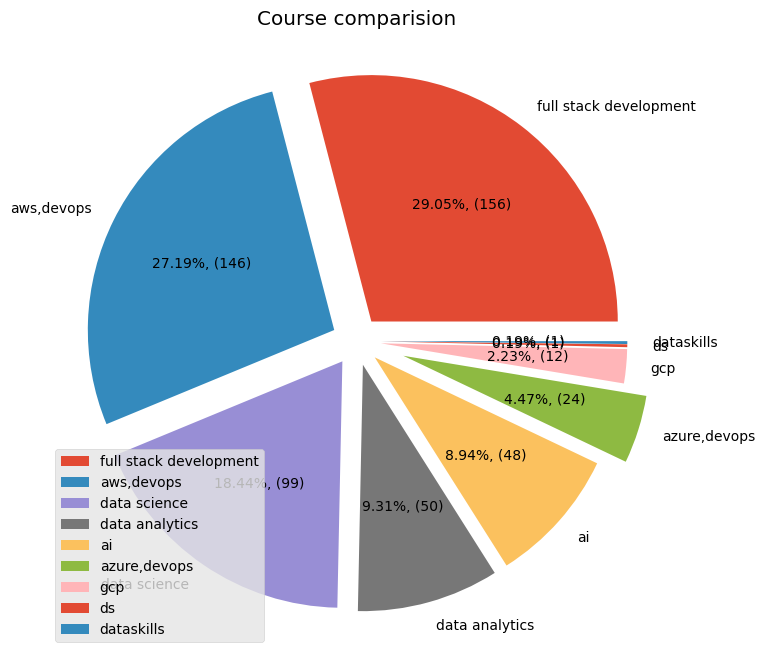

In [73]:
# Column Data: Category

classes = data['CourseName'].value_counts().index
vals = data['CourseName'].value_counts().values

plt.style.use("ggplot")
plt.figure(figsize=(8,8))
plt.pie(x = vals, labels = classes, autopct=lambda p:f'{p:.2f}%, ({p*sum(vals)/100 :.0f})', explode=[0.1, 0.1,0.1,0.1,0.1,0.2,0.1,0.1,0.1]) 
# use explode=[0.5, 0.1, 0.5, 0.1, 0.5, 0.1] for seperate pies (number of values are number of classes)
plt.title("Course comparision")
plt.legend()
plt.show()

* **Insights:**
    * Most of the institutes offer Full stack development course

##  Reach vs Day

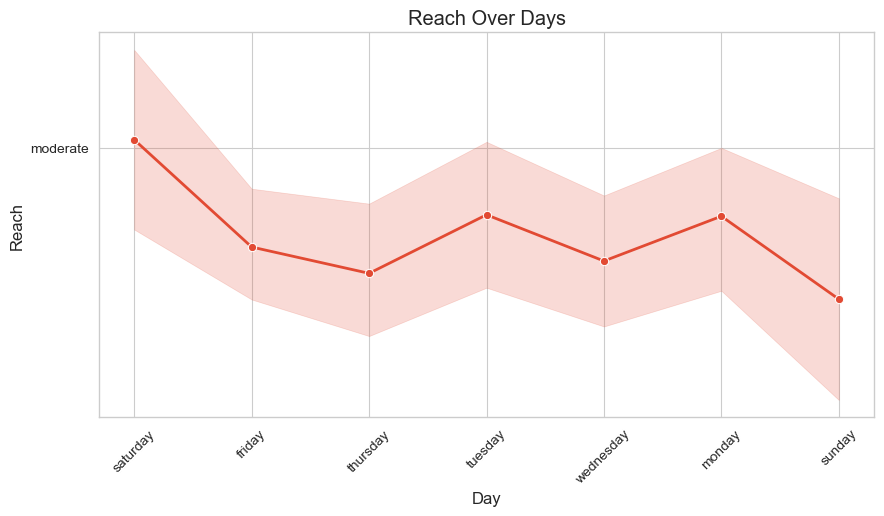

In [74]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))
sns.lineplot(x='Day', y='Reach', data=data, marker='o', linewidth=2)
plt.title("Reach Over Days")
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.show()

* On saturday we have high reach of post

                                                                Bar Chart
    -> syntax: plt.bar(classes, vals)

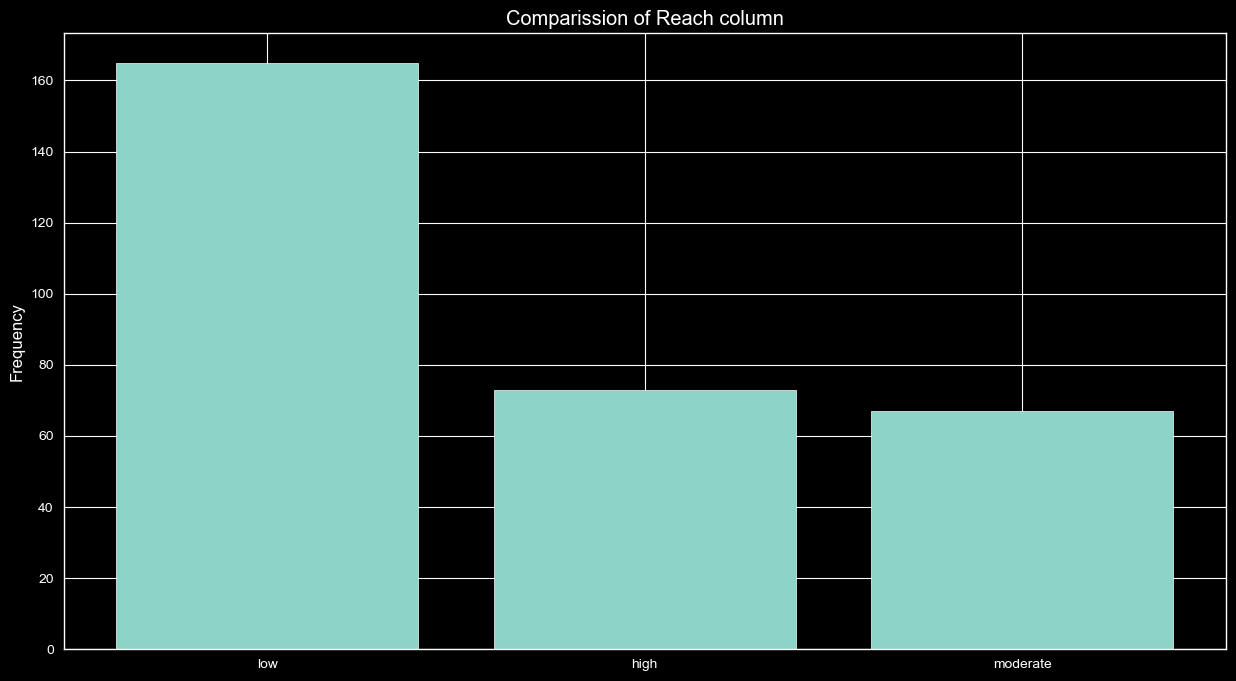

In [75]:
# Column Data: Region

classes = data['Reach'].value_counts().index
vals = data['Reach'].value_counts().values

plt.style.use("dark_background")
plt.figure(figsize=(15,8))
plt.bar(classes, vals)
plt.title("Comparission of Reach column")
plt.ylabel("Frequency")
plt.show()

* Most of posts or reels have low reach.

                                                     Numeric Col Data

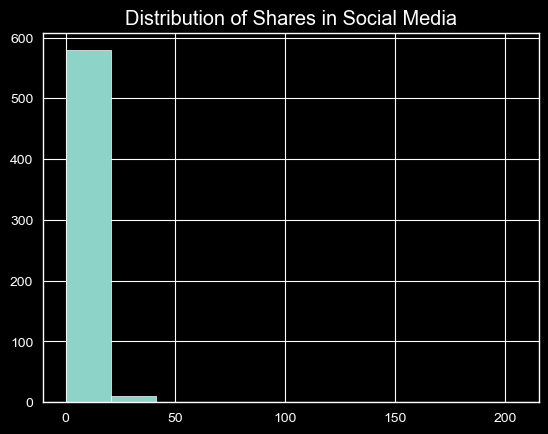

In [76]:
# Column Data: Salary

plt.hist(data['Share'])
plt.title("Distribution of Shares in Social Media")
plt.show()

* **Bi-Variate Graphs**

                                                    N-N

                                                 Scatter Plot
      -> syntax: plt.scatter(data,x,y)

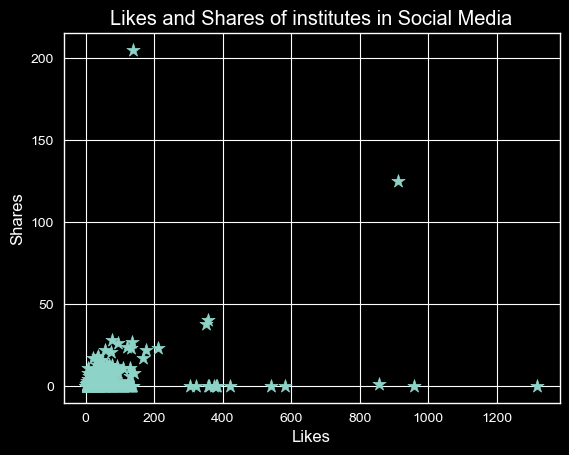

In [77]:
# # Column Data: Shares and Likes

plt.scatter(data = data, x='Likes', y='Share', s=100, marker='*')
plt.title("Likes and Shares of institutes in Social Media")
plt.xlabel("Likes")
plt.ylabel("Shares")
plt.show()

* The data shows that there is weak positive correlation between Likes and Shares

<Axes: title={'center': 'Comparision ofInstitutes'}, ylabel='Institute Name'>

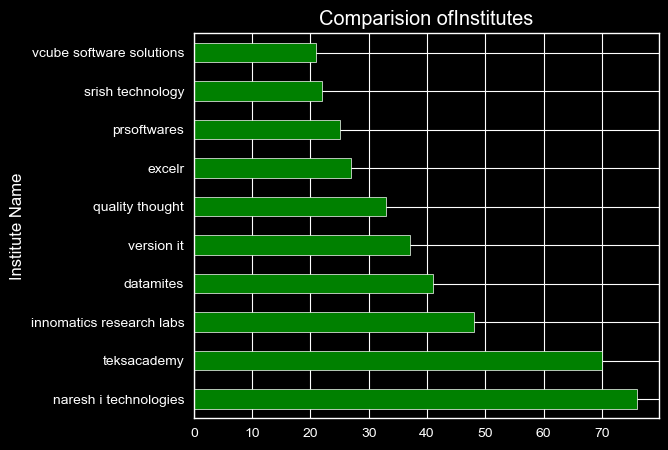

In [78]:
# Horizontal Bargraph: 
# Column Data: Area
data['Institute Name'].value_counts().sort_values(ascending=False)[0:10].plot(kind='barh', color='green', figsize=(6,5), title='Comparision ofInstitutes')                                                 

* naresh i technologies institute have more number of posts or reels.

<Axes: >

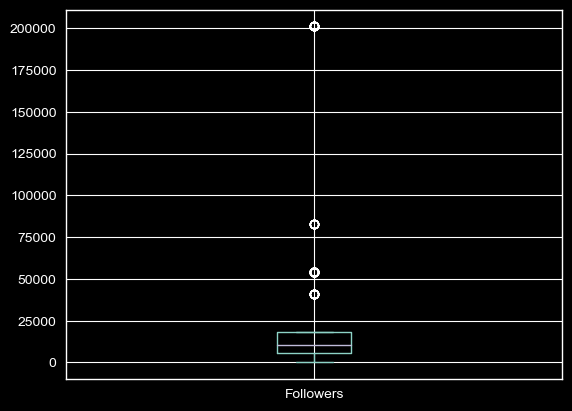

In [79]:
# Boxplot: 
# Column Data: Followers
data['Followers'].plot(kind='box')

<Axes: ylabel='Density'>

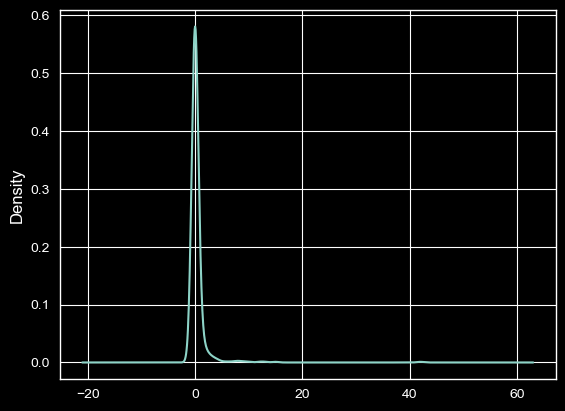

In [80]:
# Kde plot: 
# Column Data:Comments
data['Comments'].plot(kind='kde')

<Axes: xlabel='Likes', ylabel='Share'>

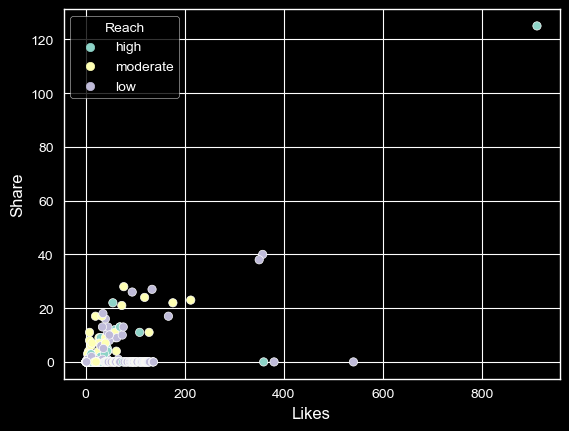

In [81]:
# Scatter plot : 
# Column Data: Shares Vs Likes with Reach

sns.scatterplot(data=data, x='Likes', y='Share', hue='Reach')

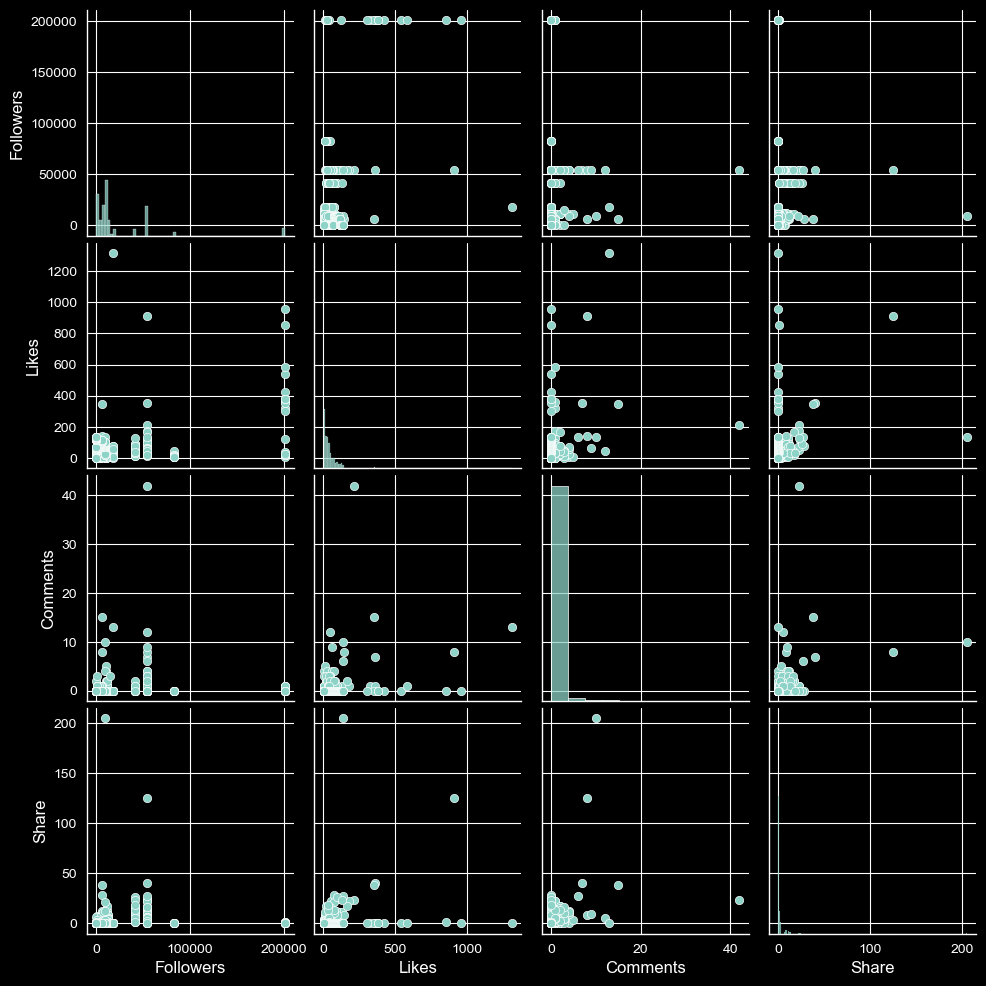

In [82]:
sns.pairplot(data)

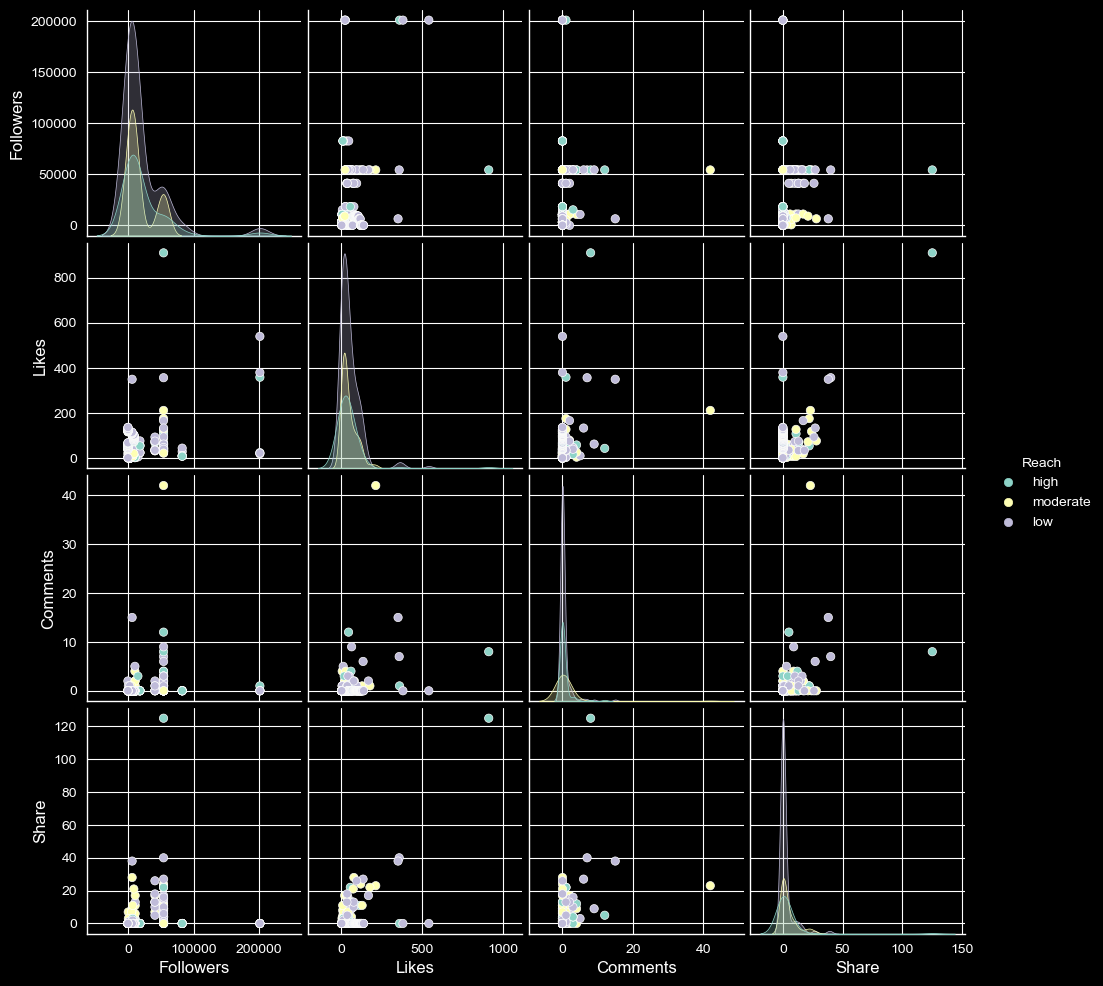

In [83]:
sns.pairplot(data, hue='Reach') # For the hue we need to always take categorical col

<Axes: >

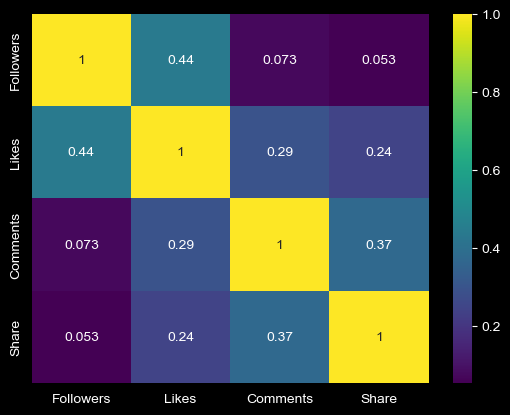

In [84]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='viridis')

* There are no strong correlations found between numeric columns.

In [85]:
data.columns

Index(['Institute Name', 'CourseName', 'Platform', 'Followers', 'type',
       'Likes', 'Comments', 'Share', 'Location', 'Reach', 'Day'],
      dtype='object')

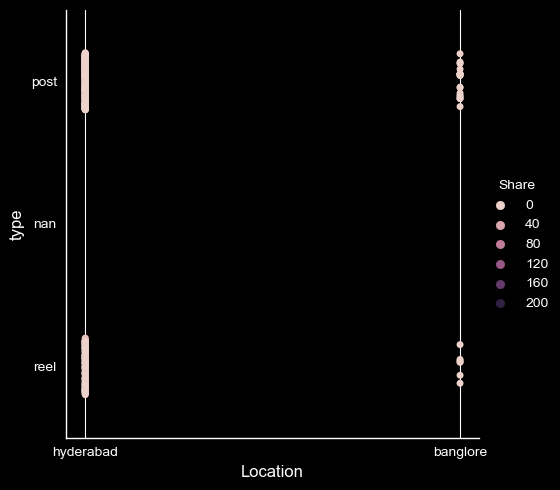

In [86]:
# Catplots: MultiVariate plots
sns.catplot(data=data, y='type', x='Location', hue='Share', orient='h')

**Overall Insights on Data**
* **Uni-Variate Insights**
* There are 21 institutes data in the datset and more posts of naresh i techologies.
* There are 9 different course posts or reels in data and more posts or reels on full stack development course.
* Data is collected from instagram
* Average follwers are 23126.
* Most of the content is uploaded as post in social media.
* Average likes are 52
* There are minmum 0 and maximum 42 comments according to  data.
* Average shares are 2 according to data.
* Most of institutes data is from hyderabad.
* Low reach is higher in count than other.
* There are more number of posts or reels posted on tuesday.
* **Study of Data between two or more columns**
* No Strong correlations found between numeric columns
    * There is weak positive correlation between likes vs shares and followers vs likes
* More posts or reels have low reach.
* There are more number of posts than reels
* Nxtwave disruptive technologies posts or reels have more number of likes
* AWS,Devops course has more number of likes

### 3. Missing Values & Outlier Handling<a id=naout>
    
[Back to Top](#menu)

#### 3.1 Missing Values

**Once we have a dataset collected, validated & analyzed, then before entering into predictive modeling we can do na & out handling , because most of the algorithms in predictive modeling can not accept missing values and also don't give better performance for outliers.**

* We need to find and handle both of them

In [87]:
vdata = data.copy()

* Empty values or any data point which is not belongs to column
* Identify Missing Values
    - Check for Standard & Non-Standard nan values 
* Handle the Missing Values
    - Drop (Row, Column)
    - Replace (MCT, Imputation, etc...)

**a) Identification**

                                                     Column Wise

In [88]:
# pandas function for each column missing values count

vdata.isnull().sum()

Institute Name     40
CourseName         63
Platform           20
Followers          23
type               29
Likes              15
Comments           12
Share               8
Location            1
Reach             295
Day                38
dtype: int64

* All the columns are having missing values

* if any feature/column having more than 70% of the data missing then we can consider it for drop
    - if we consider column importance for business then we need to replace values with variety of data

In [89]:
# Checking Na count percentage for each column

round((vdata.isnull().sum()/len(vdata))*100,2)

Institute Name     6.67
CourseName        10.50
Platform           3.33
Followers          3.83
type               4.83
Likes              2.50
Comments           2.00
Share              1.33
Location           0.17
Reach             49.17
Day                6.33
dtype: float64

                                                            Row

* For the row wise drop , pick rows having missing values more than half of the columns
* We can pick these rows and we can drop them

In [90]:
vdata[vdata.isnull().sum(axis=1)>=6]

# we have 11 columns , considering 6 half of the cols data in row

,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Location,Reach,Day
338,NaN,NaN,insta,NaN,NaN,9.0,NaN,0.0,hyderabad,NaN,NaN
590,srish technology,NaN,NaN,NaN,NaN,NaN,0.0,NaN,hyderabad,low,NaN
591,version it,NaN,insta,NaN,NaN,NaN,NaN,NaN,hyderabad,low,NaN
592,version it,NaN,NaN,NaN,NaN,NaN,2.0,NaN,hyderabad,low,NaN
594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hyderabad,low,NaN
595,social prachar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hyderabad,NaN,NaN
596,NaN,NaN,insta,NaN,NaN,NaN,NaN,NaN,hyderabad,low,NaN
597,srish technology,NaN,insta,NaN,NaN,NaN,NaN,NaN,hyderabad,low,NaN
599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Rows Found with half missing data

In [91]:
###### To Drop rows having more than half na values 

###### Taking Indexes of that rows

allnaindx = vdata[vdata.isnull().sum(axis=1)>=6].index

print("9 rows deleted",len(allnaindx))

##### Drop the above all na indx

vdata = vdata.drop(allnaindx, axis=0).reset_index(drop=True)

9 rows deleted 9


In [92]:
vdata.shape

(591, 11)

* Check of missing values after drop method

In [93]:
vdata.isnull().sum()

Institute Name     36
CourseName         54
Platform           15
Followers          14
type               20
Likes               7
Comments            5
Share               0
Location            0
Reach             292
Day                29
dtype: int64

In [94]:
vdata.dtypes

Institute Name     object
CourseName         object
Platform           object
Followers         float64
type               object
Likes             float64
Comments          float64
Share             float64
Location           object
Reach              object
Day                object
dtype: object

#### b.2) Replace 
    Replacing Missing Values can be done Col wise

In [95]:
# numeric columns replaced with median
vdata.Followers.fillna(vdata.Followers.median(), inplace=True)
vdata.Likes.fillna(vdata.Likes.median(), inplace=True)
vdata.Comments.fillna(vdata.Comments.median(), inplace=True)
vdata.Share.fillna(vdata.Share.median(), inplace=True)

In [96]:
vdata.isnull().sum()

Institute Name     36
CourseName         54
Platform           15
Followers           0
type               20
Likes               0
Comments            0
Share               0
Location            0
Reach             292
Day                29
dtype: int64

###### categorical column null value replacement with least mode

In [97]:
vdata['Day'].value_counts()

Day
tuesday      100
monday        93
thursday      91
wednesday     88
friday        86
saturday      71
sunday        33
Name: count, dtype: int64

In [98]:
vdata[vdata['Day'].isnull()].index

Index([  3,   6,  11,  13,  15,  17,  40,  49,  58,  64,  71, 115, 151, 209,
       272, 277, 321, 339, 344, 355, 393, 398, 426, 519, 569, 571, 577, 583,
       590],
      dtype='int64')

In [99]:
indexes11=vdata[vdata['Day'].isnull()].index

In [100]:
len(indexes11)

29

In [101]:
vdata['Day'].iloc[indexes11[0:9]]='friday'
vdata['Day'].iloc[indexes11[9:18]]='saturday'
vdata['Day'].iloc[indexes11[18:]]='sunday'

In [102]:
# first check for mode of that column
vdata['Institute Name'].mode()

0    naresh i technologies
Name: Institute Name, dtype: object

In [103]:
vdata['Institute Name'].value_counts()

Institute Name
naresh i technologies              76
teksacademy                        70
innomatics research labs           48
datamites                          41
version it                         35
quality thought                    33
excelr                             27
prsoftwares                        25
vcube software solutions           21
srish technology                   20
fullstackacademy                   20
fita academy                       19
cedlearn                           19
nxtwave disruptive technologies    18
mindmajix                          18
elearn infotech                    14
harsha trainings                   14
brolly academy                     13
besant technologies                10
saidemy                             9
social prachar                      5
Name: count, dtype: int64

In [104]:
# 36 null values in Institute Name column(12+12+12=36)


In [105]:
vdata[vdata['Institute Name'].isnull()].index

Index([  4,   6,  12,  13,  21,  26,  29,  38,  45,  61,  65, 110, 115, 118,
       120, 145, 150, 197, 198, 207, 211, 263, 267, 274, 279, 343, 346, 391,
       397, 406, 414, 422, 432, 558, 572, 578],
      dtype='int64')

In [106]:
indexes=vdata[vdata['Institute Name'].isnull()].index

In [107]:
indexes

Index([  4,   6,  12,  13,  21,  26,  29,  38,  45,  61,  65, 110, 115, 118,
       120, 145, 150, 197, 198, 207, 211, 263, 267, 274, 279, 343, 346, 391,
       397, 406, 414, 422, 432, 558, 572, 578],
      dtype='int64')

In [108]:
len(indexes)

36

In [109]:
vdata['Institute Name'].iloc[indexes[0:12]]='besant technologies'
vdata['Institute Name'].iloc[indexes[12:24]]='saidemy'
vdata['Institute Name'].iloc[indexes[24:]]='social prachar'

                                                    CourseName

In [110]:
vdata['CourseName'].value_counts()

CourseName
full stack development    156
aws,devops                146
data science               99
data analytics             50
ai                         48
azure,devops               24
gcp                        12
ds                          1
dataskills                  1
Name: count, dtype: int64

In [111]:
vdata[vdata['CourseName'].isnull()].index

Index([  8,  16,  19,  39,  58, 145, 193, 197, 205, 210, 217, 220, 222, 224,
       265, 271, 304, 308, 312, 318, 341, 344, 346, 349, 355, 356, 361, 363,
       367, 371, 375, 377, 378, 382, 402, 405, 417, 423, 427, 470, 473, 476,
       479, 518, 554, 559, 566, 571, 576, 579, 580, 584, 588, 590],
      dtype='int64')

In [112]:
indexes1=vdata[vdata['CourseName'].isnull()].index

In [113]:
len(indexes1) # 54=18+18+18

54

In [114]:
vdata['CourseName'].iloc[indexes1[0:18]]='gcp'
vdata['CourseName'].iloc[indexes1[18:36]]='ds'
vdata['CourseName'].iloc[indexes1[36:]]='dataskills'

In [115]:
vdata.isnull().sum()

Institute Name      0
CourseName          0
Platform           15
Followers           0
type               20
Likes               0
Comments            0
Share               0
Location            0
Reach             292
Day                 0
dtype: int64

                            platform

In [116]:
vdata['Platform'].value_counts()

Platform
insta    576
Name: count, dtype: int64

In [117]:
vdata.Platform.fillna(vdata.Platform.mode()[0], inplace=True)

In [118]:
vdata['type'].value_counts()

type
post    402
reel    169
Name: count, dtype: int64

In [119]:
vdata[vdata['type'].isnull()].index

Index([  6,  12,  15,  27,  56, 211, 272, 278, 320, 343, 354, 377, 403, 418,
       518, 564, 574, 579, 584, 590],
      dtype='int64')

In [120]:
indexes23=vdata[vdata['type'].isnull()].index

In [121]:
len(indexes23)

20

In [122]:
vdata['type'].iloc[indexes23[0:20]]='reel'

In [123]:
vdata.isnull().sum()

Institute Name      0
CourseName          0
Platform            0
Followers           0
type                0
Likes               0
Comments            0
Share               0
Location            0
Reach             292
Day                 0
dtype: int64

                                        Reach

In [124]:
vdata['Reach'].value_counts()

Reach
low         159
high         73
moderate     67
Name: count, dtype: int64

In [125]:
vdata[vdata['Reach'].isnull()].index

Index([  5,   7,   8,  11,  17,  18,  20,  23,  24,  26,
       ...
       548, 555, 556, 557, 565, 580, 581, 582, 583, 584],
      dtype='int64', length=292)

In [126]:
indexes45=vdata[vdata['Reach'].isnull()].index

In [127]:
len(indexes45)

292

In [128]:
vdata['Reach'].iloc[indexes45[0:97]]='moderate'
vdata['Reach'].iloc[indexes45[97:194]]='high'
vdata['Reach'].iloc[indexes45[194:]]='low'

In [129]:
vdata.isnull().sum()

Institute Name    0
CourseName        0
Platform          0
Followers         0
type              0
Likes             0
Comments          0
Share             0
Location          0
Reach             0
Day               0
dtype: int64

In [130]:
vdata

,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Location,Reach,Day
0,quality thought,ai,insta,10700.0,post,5.0,0.0,0.0,hyderabad,high,saturday
1,quality thought,ai,insta,10700.0,post,5.0,4.0,0.0,hyderabad,moderate,friday
2,quality thought,ai,insta,10700.0,post,11.0,5.0,3.0,hyderabad,low,thursday
3,quality thought,ai,insta,10226.0,post,6.0,0.0,4.0,hyderabad,moderate,friday
4,besant technologies,ai,insta,10700.0,post,14.0,0.0,0.0,hyderabad,low,tuesday
...,...,...,...,...,...,...,...,...,...,...,...
586,srish technology,"aws,devops",insta,114.0,reel,136.0,0.0,0.0,hyderabad,low,wednesday
587,version it,"azure,devops",insta,129.0,reel,137.0,0.0,0.0,hyderabad,low,thursday
588,version it,dataskills,insta,129.0,reel,29.0,0.0,0.0,hyderabad,low,thursday
589,srish technology,"aws,devops",insta,114.0,post,2.0,0.0,0.0,hyderabad,moderate,wednesday


**3.2 Outliers**

In [131]:
from outlier import outlier_detect, outlier_replacement

In [132]:
outcols = outlier_detect(vdata)

Column: Followers
------------------------------------------------
Boxplot For Outlier Identification:



********* Outlier Data Points *******

Lower Outliers:
[]


Upper Outliers:
[41200.0, 54300.0, 54368.0, 82672.0, 200978.0]


Column: Likes
------------------------------------------------
Boxplot For Outlier Identification:



********* Outlier Data Points *******

Lower Outliers:
[]


Upper Outliers:
[125.0, 126.0, 127.0, 128.0, 129.0, 130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0, 137.0, 142.0, 167.0, 176.0, 212.0, 304.0, 323.0, 350.0, 356.0, 357.0, 359.0, 373.0, 380.0, 382.0, 422.0, 540.0, 583.0, 857.0, 910.0, 959.0, 1317.0]


Column: Comments
------------------------------------------------
Boxplot For Outlier Identification:



********* Outlier Data Points *******

Lower Outliers:
[]


Upper Outliers:
[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 12.0, 13.0, 15.0, 42.0]


Column: Share
------------------------------------------------
Boxplot For Outlier Identification:



********* Outlier Data Points *******

Lower Outliers:
[]


Upper Outliers:
[6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 15.0, 16.0, 17.0, 18.0, 21.0, 22.0, 23.0, 24.0, 26.0, 27.0, 28.0, 38.0, 40.0, 125.0, 205.0]




In [133]:
outlier_replacement(vdata, outcols)

Column: Followers
------------------------------------------------
Replacing Outliers with 5th percentile for lower Outliers, 95th percentile for Upper Outliers....
Adjust the module code for any other replacements.........

Column: Likes
------------------------------------------------
Replacing Outliers with 5th percentile for lower Outliers, 95th percentile for Upper Outliers....
Adjust the module code for any other replacements.........

Column: Comments
------------------------------------------------
Replacing Outliers with 5th percentile for lower Outliers, 95th percentile for Upper Outliers....
Adjust the module code for any other replacements.........

Column: Share
------------------------------------------------
Replacing Outliers with 5th percentile for lower Outliers, 95th percentile for Upper Outliers....
Adjust the module code for any other replacements.........



In [134]:
# Final Check of Outliers

outlier_detect(vdata)

Column: Followers
------------------------------------------------
Boxplot For Outlier Identification:



********* Outlier Data Points *******

Lower Outliers:
[]


Upper Outliers:
[54368.0]


Column: Likes
------------------------------------------------
Boxplot For Outlier Identification:



********* Outlier Data Points *******

Lower Outliers:
[]


Upper Outliers:
[130.0]


Column: Comments
------------------------------------------------
Boxplot For Outlier Identification:



********* Outlier Data Points *******

Lower Outliers:
[]


Upper Outliers:
[2.0]


Column: Share
------------------------------------------------
Boxplot For Outlier Identification:



********* Outlier Data Points *******

Lower Outliers:
[]


Upper Outliers:
[11.0]




['Followers', 'Likes', 'Comments', 'Share']

* Almost all the outliers in columns are replaced

### 4. Predictive Modeling<a id=pm>
    
[Back to Top](#menu)
    
* Building a predictive model/trained algorithm to get the relation betweeen one col(y) to other columns (X)

#### 4.1 Selecting X & y <a id=xy>
    
[Back to Top](#menu)

* Selecting Output column (y) - future prediction column & Input column/columns (X) - Reference columns

    -  X (independent variables/input columns/explanatory variables)
    - y (dependent variable/output column/response column

In [135]:
vdata.head(2)

,Institute Name,CourseName,Platform,Followers,type,Likes,Comments,Share,Location,Reach,Day
0,quality thought,ai,insta,10700.0,post,5.0,0.0,0.0,hyderabad,high,saturday
1,quality thought,ai,insta,10700.0,post,5.0,2.0,0.0,hyderabad,moderate,friday


In [136]:
vdata.to_csv("powerbi.csv",index=False)

* For this we dataset we want to predict Class Reach, taking **Reach column as Output (y)**
    - **Remaining Columns data can be taken as input (X)**

In [137]:
#df = df.drop(columns=['B', 'C'])
#X=vdata.drop(columns=['Platform','Likes','Comments','Share','Reach'])
X=vdata[['Institute Name','CourseName','Followers','type','Location','Day']]

In [138]:
y=vdata['Reach']

In [139]:
X.head(2)

,Institute Name,CourseName,Followers,type,Location,Day
0,quality thought,ai,10700.0,post,hyderabad,saturday
1,quality thought,ai,10700.0,post,hyderabad,friday


In [140]:
y.head(2)

0        high
1    moderate
Name: Reach, dtype: object

In [141]:
print("Input Columns Data (X):")
display(X.head())
print()
print("Output Column Data (y):")
display(y.head())

Input Columns Data (X):


,Institute Name,CourseName,Followers,type,Location,Day
0,quality thought,ai,10700.0,post,hyderabad,saturday
1,quality thought,ai,10700.0,post,hyderabad,friday
2,quality thought,ai,10700.0,post,hyderabad,thursday
3,quality thought,ai,10226.0,post,hyderabad,friday
4,besant technologies,ai,10700.0,post,hyderabad,tuesday



Output Column Data (y):


0        high
1    moderate
2         low
3    moderate
4         low
Name: Reach, dtype: object

In [142]:
y.value_counts()

Reach
low         257
high        170
moderate    164
Name: count, dtype: int64

y column is balanced

#### 4.2  Feature Engineering of X<a id=fe>

[Back to Top](#menu)

* Generation/ Modification / Deletion / Selection of X columns/features according to y column

In [143]:
X.head()

,Institute Name,CourseName,Followers,type,Location,Day
0,quality thought,ai,10700.0,post,hyderabad,saturday
1,quality thought,ai,10700.0,post,hyderabad,friday
2,quality thought,ai,10700.0,post,hyderabad,thursday
3,quality thought,ai,10226.0,post,hyderabad,friday
4,besant technologies,ai,10700.0,post,hyderabad,tuesday


* Need to handle Institute Name,Course name,type,Location,Date

#### 4.2.1 Feature Generation

* Done in Data validation

#### 4.2.2 Feature Selection/Deletion

**Considering all the  columns for predictive modeling, as each column has its own importance to Reach**

* If the model performance is not ok, then we can comeback to this step and we can select imp x features using statistical analysis

In [144]:
# Saving Data for UserInput
X.to_csv("inputdata.csv",index=False)

In [145]:
df = X.copy()

In [146]:
df.head()

,Institute Name,CourseName,Followers,type,Location,Day
0,quality thought,ai,10700.0,post,hyderabad,saturday
1,quality thought,ai,10700.0,post,hyderabad,friday
2,quality thought,ai,10700.0,post,hyderabad,thursday
3,quality thought,ai,10226.0,post,hyderabad,friday
4,besant technologies,ai,10700.0,post,hyderabad,tuesday


#### 4.2.3 Feature Modification (Data Pre-Processing)

**Encoding**

* Converting categorical data to numeric

In [147]:
# Selecting Categorical Data
X.select_dtypes("O").head()

,Institute Name,CourseName,type,Location,Day
0,quality thought,ai,post,hyderabad,saturday
1,quality thought,ai,post,hyderabad,friday
2,quality thought,ai,post,hyderabad,thursday
3,quality thought,ai,post,hyderabad,friday
4,besant technologies,ai,post,hyderabad,tuesday


In [148]:
cat_cols = X.select_dtypes("O")

In [149]:
cat_cols

,Institute Name,CourseName,type,Location,Day
0,quality thought,ai,post,hyderabad,saturday
1,quality thought,ai,post,hyderabad,friday
2,quality thought,ai,post,hyderabad,thursday
3,quality thought,ai,post,hyderabad,friday
4,besant technologies,ai,post,hyderabad,tuesday
...,...,...,...,...,...
586,srish technology,"aws,devops",reel,hyderabad,wednesday
587,version it,"azure,devops",reel,hyderabad,thursday
588,version it,dataskills,reel,hyderabad,thursday
589,srish technology,"aws,devops",post,hyderabad,wednesday


* **Checking number of categories in above columns and applying encoding techniques**

In [150]:
for col in cat_cols:
    print(col, ":", cat_cols[col].nunique())
    print(cat_cols[col].unique())
    print()

Institute Name : 21
['quality thought' 'besant technologies' 'naresh i technologies'
 'innomatics research labs' 'fullstackacademy' 'saidemy' 'teksacademy'
 'datamites' 'cedlearn' 'elearn infotech'
 'nxtwave disruptive technologies' 'excelr' 'social prachar'
 'fita academy' 'mindmajix' 'brolly academy' 'prsoftwares'
 'harsha trainings' 'vcube software solutions' 'version it'
 'srish technology']

CourseName : 9
['ai' 'data analytics' 'gcp' 'data science' 'ds' 'dataskills'
 'full stack development' 'aws,devops' 'azure,devops']

type : 2
['post' 'reel']

Location : 2
['hyderabad' 'banglore']

Day : 7
['saturday' 'friday' 'thursday' 'tuesday' 'wednesday' 'monday' 'sunday']



* From above, each column is having more than two classes except platform,type,location
* Need to Identify ordinal and nominal columns to apply proper encoding
    - Ordinal Encoding - for Ordinal Cols
    - One-Hot Encoding - for Nominal Cols

* From Business Pov we can consider,

      Binary columns: type,location
      Ordinal columns: Day,course name
      Nominal columns: institute name

                               Binary encoding-- type

In [151]:
X.type.unique()

array(['post', 'reel'], dtype=object)

In [152]:
X.type.replace({'post':0,'reel':1}, inplace=True)

                            Binary encoding-location

In [153]:
X.Location.unique()

array(['hyderabad', 'banglore'], dtype=object)

In [154]:
X.Location.replace({'hyderabad':0,'banglore':1}, inplace=True)

* **Ordinal Columns Data Encoding**

In [155]:
X[['Day','CourseName']]

,Day,CourseName
0,saturday,ai
1,friday,ai
2,thursday,ai
3,friday,ai
4,tuesday,ai
...,...,...
586,wednesday,"aws,devops"
587,thursday,"azure,devops"
588,thursday,dataskills
589,wednesday,"aws,devops"


* We can replace above cat classes with ordinal numbers, 
    - Those numbers can be,
        - target encoding: output column value according to class or
        - ordinal number according to alphabetical order
        - or our own choice of numbers

* **for the above ordinal cols considering target encoding**

In [156]:
# Writing a loop

import pickle # Module to save encoding dictionaries

for col in X[['Day','CourseName']].columns:
    # Taking value counts of each class as it represents sum of yes and no values of output column
    grouped = X[col].value_counts()
    ordencoding = {brand:value for brand, value in zip(grouped.index, grouped.values)}
    # saving above encoding for future use
    with open(f'{col}_encoding.pkl', 'wb') as f:
        pickle.dump(ordencoding, f)
        
    X[col].replace(ordencoding, inplace=True)    
    
# To load encoding for future use 

# with open('saved_dictionary.pkl', 'rb') as f:
#     loaded_dict = pickle.load(f)

In [157]:
X.head()

,Institute Name,CourseName,Followers,type,Location,Day
0,quality thought,48,10700.0,0,0,80
1,quality thought,48,10700.0,0,0,95
2,quality thought,48,10700.0,0,0,91
3,quality thought,48,10226.0,0,0,95
4,besant technologies,48,10700.0,0,0,100


* **Nominal Column Data Encoding**      - **Institute name**

In [158]:
# Library
from sklearn.preprocessing import OneHotEncoder

# Define Object
ohe = OneHotEncoder(handle_unknown='ignore')

# handle_unknown=ignore -> future classes will be ignored
# drop=first -> is another param for dummy variable trap

In [159]:
#Using fit_transform method to convert column data into onehot encodings

ohedata = ohe.fit_transform(X[['Institute Name']]).toarray()


In [160]:
ohedata

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

* Adding above one hot encoded data to X

In [161]:
# Converting to dataframe

ohedata = pd.DataFrame(ohedata, columns=ohe.get_feature_names_out())

In [162]:
ohedata

,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,Institute Name_excelr,Institute Name_fita academy,Institute Name_fullstackacademy,Institute Name_harsha trainings,Institute Name_innomatics research labs,...,Institute Name_naresh i technologies,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
587,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [163]:
# Droping  CourseName , Platform with Ohedata

X = pd.concat([X.drop(['Institute Name'], axis=1), ohedata], axis=1)

In [164]:
X.head()

,CourseName,Followers,type,Location,Day,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,...,Institute Name_naresh i technologies,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it
0,48,10700.0,0,0,80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,48,10700.0,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,48,10700.0,0,0,91,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,48,10226.0,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,48,10700.0,0,0,100,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Scaling**

* Converting main numeric columns under one scale if necessary

* Scaler Suggested if columns data is on different scales
    - Standard Scaler (-3 to +3)
    - Robust Scaler (When we have outliers in columns)
    - MinMaxScaler (-1 to +1)

* Numeric Cols are in different scales , need to apply scaling
    - Followers,Likes,Comments,share

In [165]:
X.iloc[:,[1]]

,Followers
0,10700.0
1,10700.0
2,10700.0
3,10226.0
4,10700.0
...,...
586,114.0
587,129.0
588,129.0
589,114.0


In [166]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X.iloc[:,[1]] = sc.fit_transform(X.iloc[:,[1]])

* **Final X Data for modeling**

In [167]:
X.head()

,CourseName,Followers,type,Location,Day,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,...,Institute Name_naresh i technologies,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it
0,48,-0.354727,0,0,80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,48,-0.354727,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,48,-0.354727,0,0,91,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,48,-0.378737,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,48,-0.354727,0,0,100,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


* **y data**

In [168]:
y.head()

0        high
1    moderate
2         low
3    moderate
4         low
Name: Reach, dtype: object

#### 4.3 Train-Test Split of X & y<A id=tt>
    
[Back to Top](#menu)
    
* Dividing data into two parts, train-test
    - train part used for model building
    - test part is used for model evaluation

In [169]:
# sklearn method

from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.30, random_state=123)

In [170]:
xtrain.shape, ytrain.shape  # model training data

((413, 26), (413,))

In [171]:
xtrain

,CourseName,Followers,type,Location,Day,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,...,Institute Name_naresh i technologies,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it
145,30,-0.438914,1,0,100,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
178,48,-0.278746,1,0,100,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101,99,-0.569552,1,0,44,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
537,146,-0.433646,0,0,93,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
42,99,1.857240,0,0,93,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,48,-0.334466,0,0,93,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
322,156,0.032170,0,1,100,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
382,19,-0.724959,0,0,100,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
365,156,-0.724959,0,0,93,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [172]:
print(ytrain)

145    moderate
178        high
101    moderate
537         low
42     moderate
         ...   
98     moderate
322         low
382    moderate
365        high
510         low
Name: Reach, Length: 413, dtype: object


In [173]:
xtest.shape, ytest.shape # model evaluation data

((178, 26), (178,))

**4.4 Modeling/Algorithm Training on Train Data**

* Sending xtrain & ytrain data to a algorithm, where it can study the patterns and gives predictive model to generate y for future x values

* Taken **y data is categorical**, we can apply **machine learning supervised classification algorithms**
    
* In Classification we have below algorithms
    - Logistic Regression
    - Knearest Neighbors (KNN)
    - Support Vector Machine (SVM)
    - Naive Bayes (NB)
    - Decision Trees (CART)
    - Random Forest (Bagging)
    - Xgboost (Boosting)

* Importing Sklearn Library Models Functions

In [174]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

* Model Objects Defining

In [175]:
# Model Define

log = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)


# ---------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=5, p=1)

# Here neighbors are the hyperparameter
# Distance is the another hyperparameter (p) 2 for euclidean distance

# ---------------------------------------------------------
dt = DecisionTreeClassifier() # Taking default Hyper params

# We can try hyp params:
# criteria is the root node selection method
# max_depth is the number of subtrees in decision  tree - main Hyperparameter

# -----------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=20,      # Maximum depth of trees
    min_samples_split=5, # Minimum samples required to split a node
    min_samples_leaf=2,  # Minimum samples required at a leaf node
    random_state=42
)

# Train the model on your training data
# Taking Default Hyp params

# We can try hyp params:
# n_estimators are number of decision trees - Hyper parameter

# ------------------------------------------------------------
sv = SVC(kernel = 'rbf', gamma=5) # for a non-linear seperable data

# Gamma=Sigma=coeffient for the rbf kernel - hyperparameter
# Kernel linear-- Linear SVM
#sv = SVC(kernel="linear") # for a linear separable data

# -----------------------------------------------------------
nb = GaussianNB()
    
# -----------------------------------------------------------
xgb = XGBClassifier() # Taking default Hyper params

**Model Training**

* Using xtrain, ytrain data
* Using fit command to train the defined model with xtrain, ytrain

**4.4.1 Logistic Regression**

* 
It uses the Linear Regression line to convert it into a sigmoid curve with the logit function output as probability of class

prob = 1/1+e^-y

if prob>0.5 1 
else 0

* Learning/Training Model on train data
* 
we can use fit function in model for xtrain and ytrain data to train our data for getting the line co-efficients

In [176]:
log.fit(xtrain, ytrain)

LogisticRegression(max_iter=1000, multi_class='multinomial')

Parameters

In [177]:
log.intercept_

array([-0.10874617,  1.06017485, -0.95142868])

In [178]:
log.coef_

array([[ 0.00559265,  0.16297813, -0.00342302,  0.82731525, -0.00610588,
        -0.78756503, -0.74842823,  1.42659642,  0.72519705,  1.10489414,
         0.66141562,  0.73978713, -0.83006348, -0.12543863, -0.08586275,
        -0.08583417, -0.28337096,  0.95264375,  0.28281309,  0.07779099,
         0.14560429, -0.28221196, -0.62456861, -1.27854272, -0.43609095,
        -0.49315313],
       [ 0.0024278 ,  0.05615287,  0.16139329,  0.21874226, -0.01046011,
        -0.18260513,  0.6560344 , -0.54519142, -0.85253614, -0.17479637,
        -0.17425528, -0.37496273, -0.80015518,  0.50910531, -0.91496969,
         0.47435905,  0.15011731, -0.47279522,  0.09916323, -0.13580447,
         0.17018532,  0.23109011,  0.60556788,  0.25034567,  1.08185396,
         0.54874112],
       [-0.00802045, -0.219131  , -0.15797027, -1.04605751,  0.01656598,
         0.97017016,  0.09239383, -0.881405  ,  0.12733908, -0.93009777,
        -0.48716035, -0.36482439,  1.63021865, -0.38366668,  1.00083244,
       

**4.4.2 KNN - K Nearest Neighbors**
* It will take the nearest data points using euclidean distance metric with number of k given

* It is a lazy algorithm , it wont train the data instead it will store the data

* It will do the training when test data given

In [179]:
knn.fit(xtrain, ytrain)

KNeighborsClassifier(p=1)

In [180]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 1,
 'weights': 'uniform'}

**4.4.3 Decision Tree**
* Logic Tree based predictions based on root and interior nodes, branches

In [181]:
dt.fit(xtrain, ytrain)

DecisionTreeClassifier()

* **Feature Importance**

In [182]:
pd.DataFrame(index = dt.feature_names_in_,data = [round(val,2) for val in dt.feature_importances_], columns = ['FeatureImportance'])

,FeatureImportance
CourseName,0.40
Followers,0.10
type,0.06
Location,0.02
Day,0.22
Institute Name_besant technologies,0.00
Institute Name_brolly academy,0.00
Institute Name_cedlearn,0.04
Institute Name_datamites,0.03
Institute Name_elearn infotech,0.00


* **Tree**

In [183]:
from sklearn.tree import plot_tree

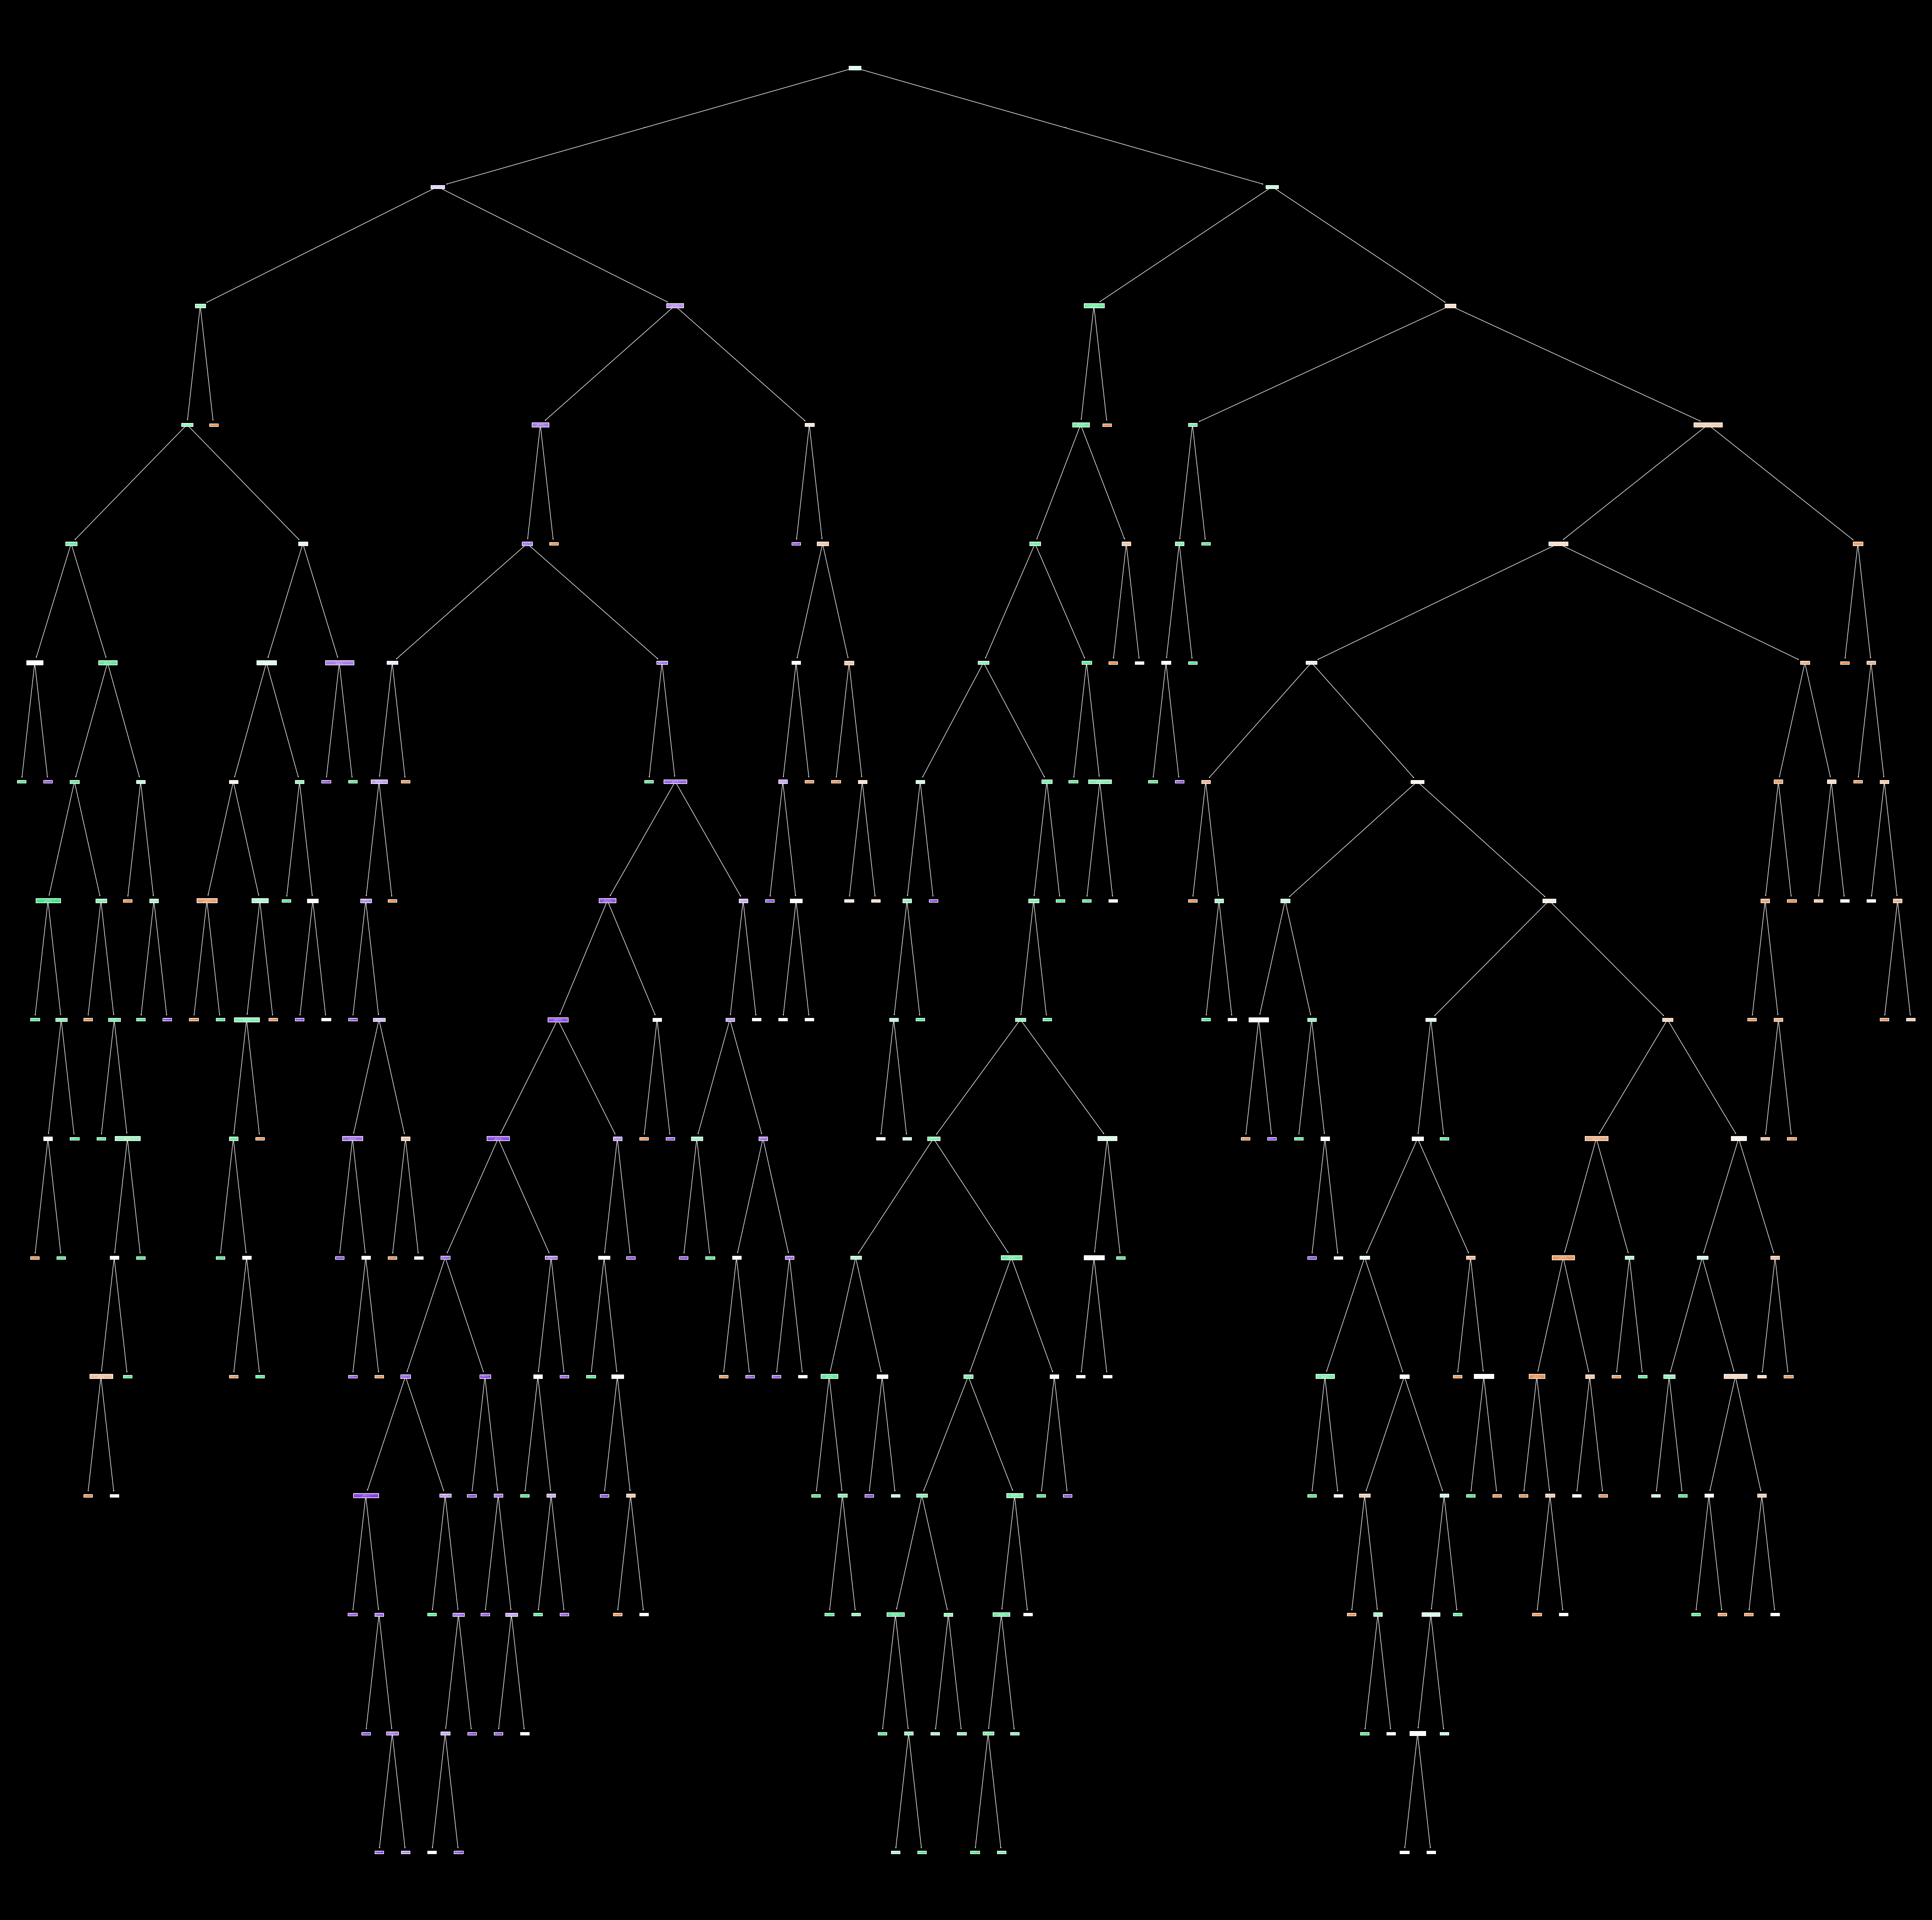

In [184]:
plt.figure(figsize = (30,30), dpi = 150)
plot_tree(dt,filled = True, feature_names=list(xtrain.columns))
plt.show()

**4.4.4 Random Forest**
* Bagging algorithm which was a combination of Multiple Decision Trees


In [185]:
rf.fit(xtrain, ytrain)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [186]:
pd.DataFrame(index = rf.feature_names_in_,data = [round(val,2) for val in rf.feature_importances_], columns = ['FeatureImportance'])

,FeatureImportance
CourseName,0.32
Followers,0.14
type,0.03
Location,0.02
Day,0.16
Institute Name_besant technologies,0.01
Institute Name_brolly academy,0.01
Institute Name_cedlearn,0.03
Institute Name_datamites,0.02
Institute Name_elearn infotech,0.02


* Trees

In [187]:
rf.estimators_

[DecisionTreeClassifier(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                        min_samples_split=5, random_state=1608637542),
 DecisionTreeClassifier(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                        min_samples_split=5, random_state=1273642419),
 DecisionTreeClassifier(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                        min_samples_split=5, random_state=1935803228),
 DecisionTreeClassifier(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                        min_samples_split=5, random_state=787846414),
 DecisionTreeClassifier(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                        min_samples_split=5, random_state=996406378),
 DecisionTreeClassifier(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                        min_samples_split=5, random_state=1201263687),
 DecisionTreeClassifier(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                       

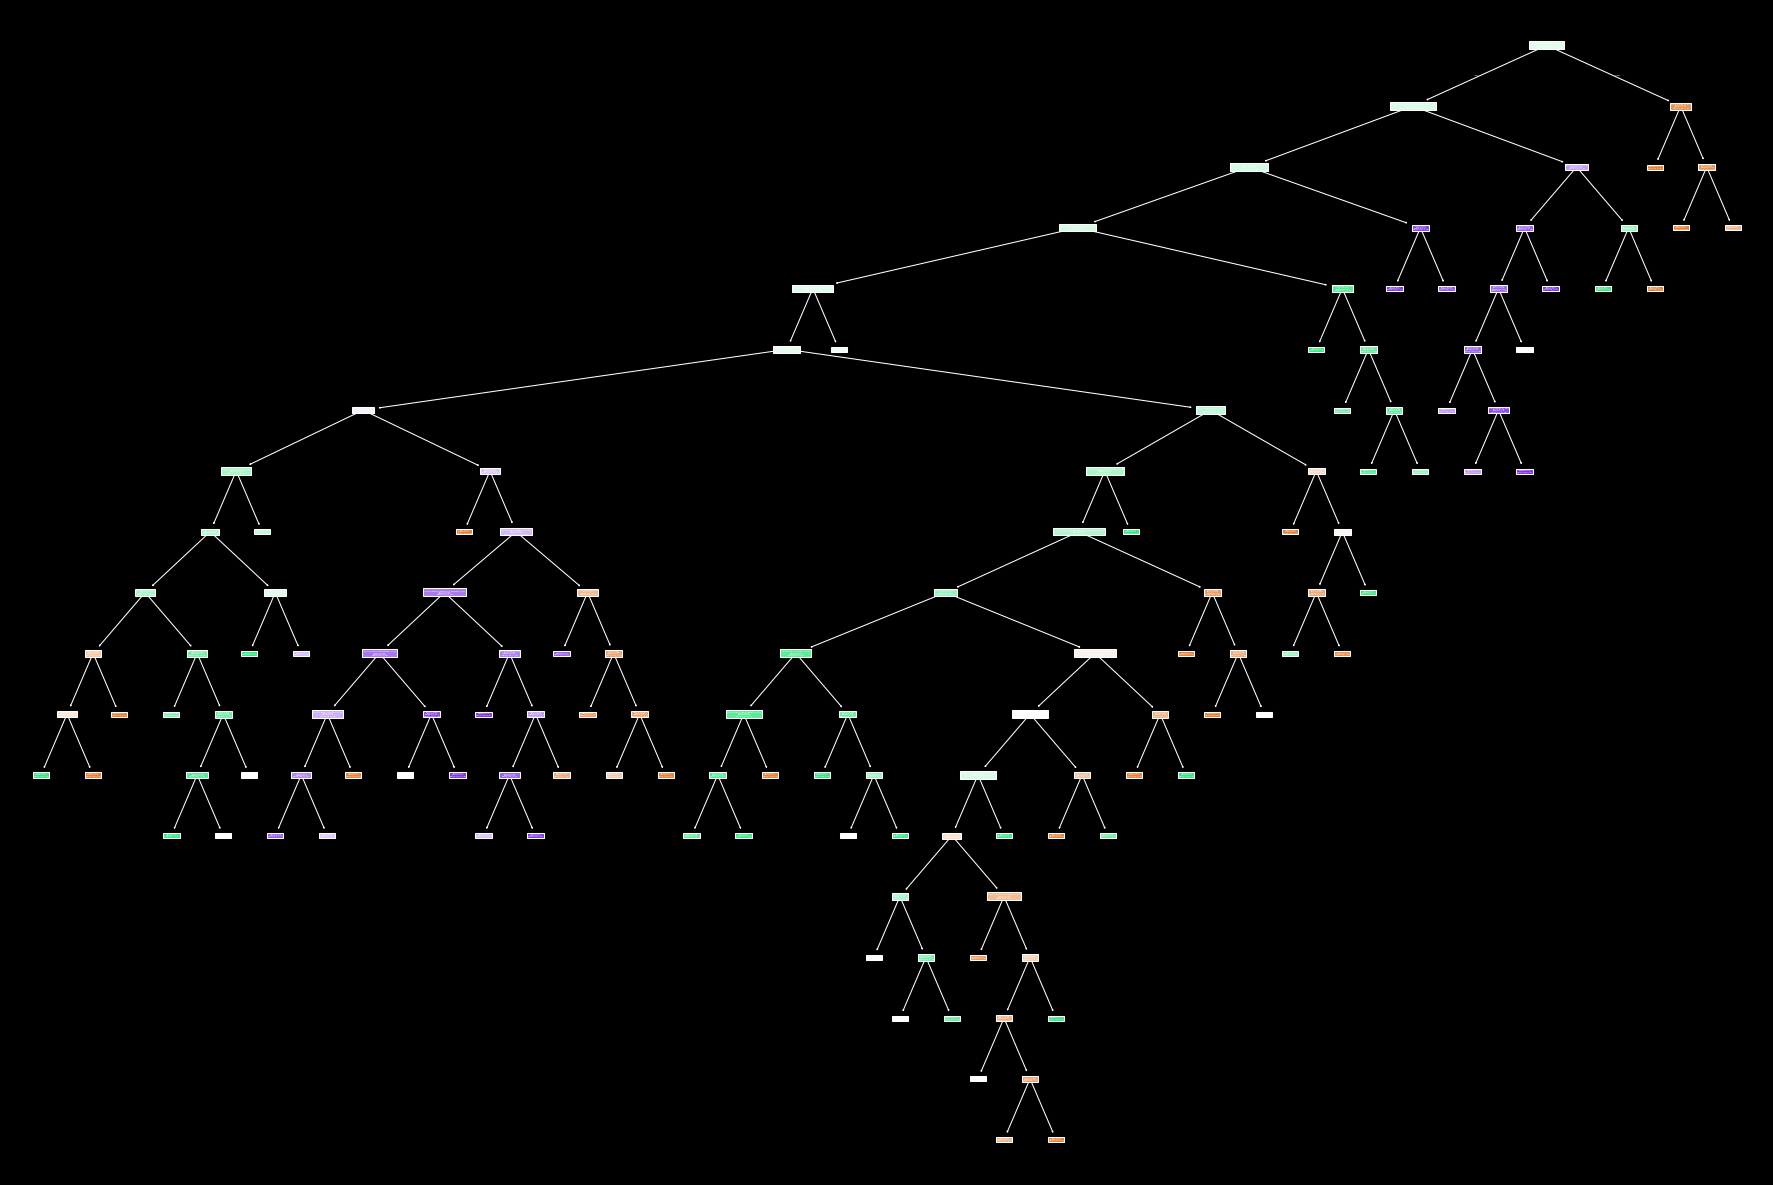

In [188]:
plt.figure(figsize = (15,10),dpi = 150)
plot_tree(rf.estimators_[1],filled = True, feature_names=xtrain.columns)
plt.show()

**4.4.5 SVM (Time Taking for Higher Dimensional Data)**
* Support vectors (Data Points grouped with Soft Margin Classifier) - for linear data

* for non-linear data kernel trick is used to divide classes - rbf , poly

In [189]:
sv.fit(xtrain, ytrain)

SVC(gamma=5)

In [190]:


sv.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 5,
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

**4.4.6 Naive Bayes**
* Naive Bayes works on Bayesian Probability formula

In [191]:
nb.fit(xtrain, ytrain)

GaussianNB()

**4.4.7 Xgboost**
* Boosting Algorithm where for the selected number of models , one model error will be trained by another model

  We need to install xgboost, using anaconda prompt - pip install xgboost

In [192]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

ytrain_xg = le.fit_transform(ytrain)

In [193]:
# xgboost accepts label data as number

ytrain_xg = np.where(ytrain == 'low', 0, np.where(ytrain == 'moderate', 1, 2))

In [194]:
xgb.fit(xtrain,ytrain_xg)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

**4.5 Test Predictions & 4.6 Model Evaluation/Performance**

* Checking Trained Model Performances on Test Data

* Using x_test data we will be getting predictions, these predictions will be compared to y_test

* To check Model Performance we can use evaluation methods

    * Error/Loss
    * Model Score 
    * Bias-Variance Trade off (Underfit or Overfit)
    * Cross-Val Score

* **For classification we can use these evaluation**
    


Performance Metric | Classification
-------|-----------
**Loss or Error**|**Confusion Matrix (Number of right/wrong predictions)**
**Model Score (Evaluation)** | **Accuracy Score (Balanced Data) , F1-Score/Auc-Roc Score (For Imbalanced Data)**
**Bias-Variance Trade Off**|Higher error & Lower score (underfit)
-|Low Train error & High Test error (Overfit)
**Cross-Val Score**|Checking trained model performance on entire X and y data

In [195]:
y.value_counts()

Reach
low         257
high        170
moderate    164
Name: count, dtype: int64

* **As we have nearly balanced data considering accuracy score for understanding model performance**

In [196]:
# Modules for Metrics

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, auc
from sklearn.model_selection import cross_val_score
from tabulate import tabulate
import numpy as np

* **Checking the above models perfomance using Test data**

In [197]:
names = ['LogisticRegression', 'KNearestNeighbors', 'SVM', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'Xgboost']

models = {'log':log,'knn':knn,'svm':sv, 'nb':nb, 'dt':dt, 'rf':rf, 'xgb':xgb}

* **Confusion_matrix , Classification_report**

Model: LogisticRegression

Classification Report:
               precision    recall  f1-score   support

        high       0.55      0.41      0.47        51
         low       0.62      0.80      0.70        80
    moderate       0.54      0.43      0.48        47

    accuracy                           0.59       178
   macro avg       0.57      0.55      0.55       178
weighted avg       0.58      0.59      0.58       178

Confusion_Matrix:


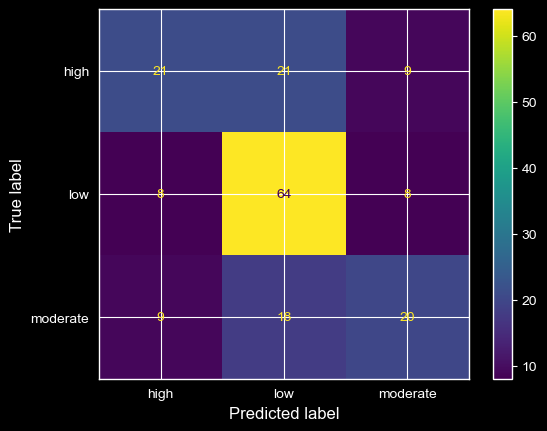

-----------------------------------------------------------------------------------
Model: KNearestNeighbors

Classification Report:
               precision    recall  f1-score   support

        high       0.50      0.47      0.48        51
         low       0.69      0.75      0.72        80
    moderate       0.58      0.53      0.56        47

    accuracy                           0.61       178
   macro avg       0.59      0.58      0.59       178
weighted avg       0.61      0.61      0.61       178

Confusion_Matrix:


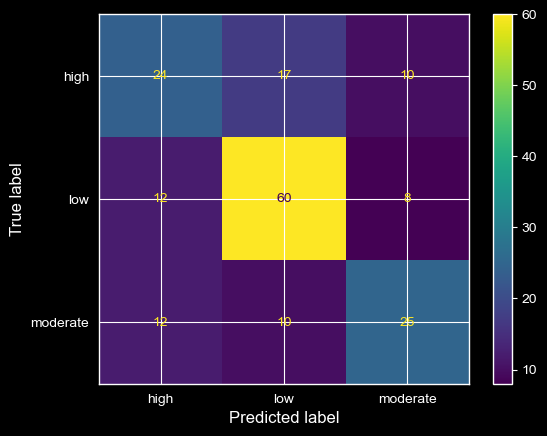

-----------------------------------------------------------------------------------
Model: SVM

Classification Report:
               precision    recall  f1-score   support

        high       0.50      0.29      0.37        51
         low       0.52      0.85      0.64        80
    moderate       0.62      0.21      0.32        47

    accuracy                           0.52       178
   macro avg       0.55      0.45      0.44       178
weighted avg       0.54      0.52      0.48       178

Confusion_Matrix:


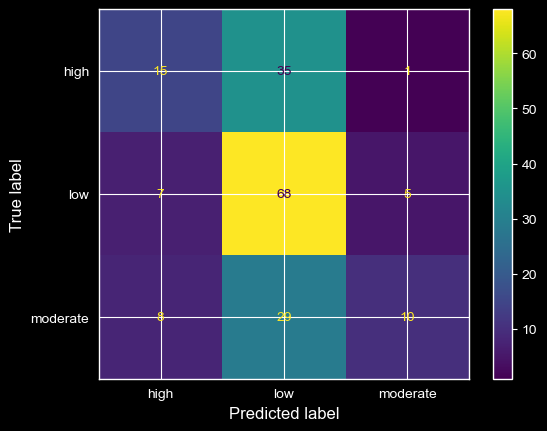

-----------------------------------------------------------------------------------
Model: Naive Bayes

Classification Report:
               precision    recall  f1-score   support

        high       0.56      0.35      0.43        51
         low       0.74      0.21      0.33        80
    moderate       0.33      0.85      0.47        47

    accuracy                           0.42       178
   macro avg       0.54      0.47      0.41       178
weighted avg       0.58      0.42      0.40       178

Confusion_Matrix:


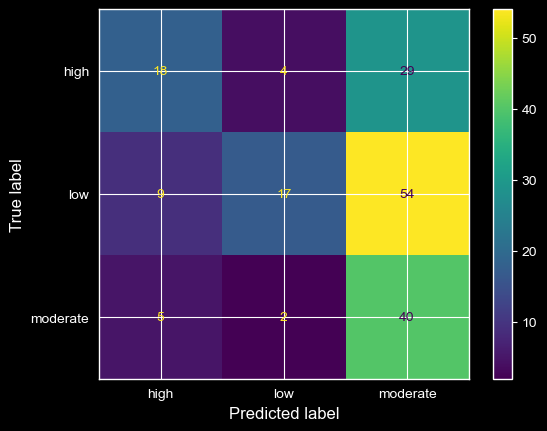

-----------------------------------------------------------------------------------
Model: Decision Tree

Classification Report:
               precision    recall  f1-score   support

        high       0.40      0.51      0.45        51
         low       0.64      0.61      0.63        80
    moderate       0.57      0.45      0.50        47

    accuracy                           0.54       178
   macro avg       0.54      0.52      0.53       178
weighted avg       0.55      0.54      0.54       178

Confusion_Matrix:


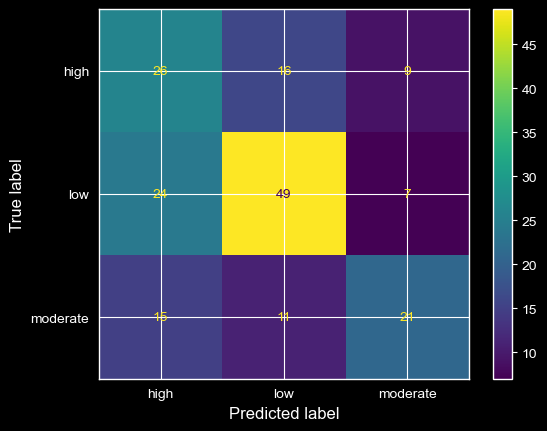

-----------------------------------------------------------------------------------
Model: Random Forest

Classification Report:
               precision    recall  f1-score   support

        high       0.56      0.47      0.51        51
         low       0.68      0.79      0.73        80
    moderate       0.64      0.57      0.61        47

    accuracy                           0.64       178
   macro avg       0.63      0.61      0.62       178
weighted avg       0.63      0.64      0.63       178

Confusion_Matrix:


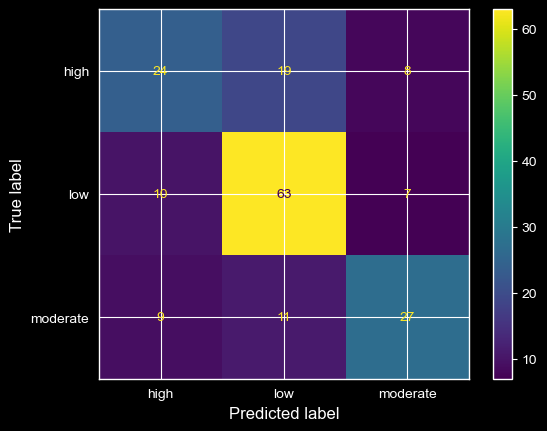

-----------------------------------------------------------------------------------
Model: Xgboost

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.68      0.67        80
           1       0.59      0.51      0.55        47
           2       0.46      0.51      0.49        51

    accuracy                           0.58       178
   macro avg       0.57      0.57      0.57       178
weighted avg       0.59      0.58      0.58       178

Confusion_Matrix:


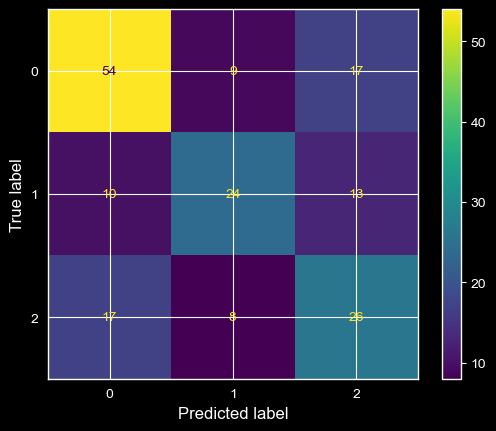

-----------------------------------------------------------------------------------


In [198]:
from simple_colors import *

n=0
for key,value in models.items():
    print(green("Model: {}\n".format(names[n]),['bold']))
    if key == 'xgb':
        ytest_pred = models[key].predict(xtest)
        ytest_xg = np.where(ytest == 'low', 0, np.where(ytest == 'moderate', 1, 2))
        print("Classification Report:\n",classification_report(ytest_xg, ytest_pred))
        print(blue("Confusion_Matrix:",['bold']))
        plt.show(ConfusionMatrixDisplay.from_estimator(models[key], xtest, ytest_xg))
        print("-----------------------------------------------------------------------------------")
    else:
        ytest_pred = models[key].predict(xtest.values)
        print("Classification Report:\n",classification_report(ytest, ytest_pred))
        print(blue("Confusion_Matrix:",['bold']))
        plt.show(ConfusionMatrixDisplay.from_estimator(models[key], xtest.values, ytest))
        print("-----------------------------------------------------------------------------------")
    n+=1

**Making Table for accuracy scores of all the models for train and test data to decide best model**

In [199]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from tabulate import tabulate
import numpy as np

results = []

for name, model in models.items():
    if name == 'xgb':
        # Processing for XGBoost model
        ytrain_xg = np.where(ytrain == 'low', 0, np.where(ytrain == 'moderate', 1, 2))
        ytest_xg = np.where(ytest == 'low', 0, np.where(ytest == 'moderate', 1, 2))

        ytrain_pred = model.predict(xtrain)
        ytest_pred = model.predict(xtest)

        # Accuracy Score
        trscore = round(accuracy_score(ytrain_xg, ytrain_pred), 2)
        tescore = round(accuracy_score(ytest_xg, ytest_pred), 2)

        # Bias-Variance Trade off
        if trscore < 0.50 and tescore < 0.50:
            if abs(trscore) == 0 and abs(tescore) == 0:
                fit = "Nofit"
            else:
                fit = "Underfit"
        else:
            if abs(trscore - tescore) < 0.10:
                fit = "Goodfit"
            elif abs(trscore - tescore) >= 0.10:
                fit = "Overfit"
            else:
                fit = "Fit"

        y_xg = np.where(y == 'low', 0, np.where(y == 'moderate', 1, 2))

        # Cross-val score
        scores = cross_val_score(model, X, y_xg, cv=2, scoring='f1_micro')
        crossvalscore = round(scores.mean(), 2)

    else:
        # Processing for other models
        ytrain_pred = model.predict(xtrain.values)
        ytest_pred = model.predict(xtest.values)

        # Accuracy Score
        trscore = round(accuracy_score(ytrain, ytrain_pred), 2)
        tescore = round(accuracy_score(ytest, ytest_pred), 2)

        # Bias-Variance Trade off
        if trscore < 0.50 and tescore < 0.50:
            if abs(trscore) == 0 and abs(tescore) == 0:
                fit = "Nofit"
            else:
                fit = "Underfit"
        else:
            if abs(trscore - tescore) < 0.10:
                fit = "Goodfit"
            elif abs(trscore - tescore) >= 0.10:
                fit = "Overfit"
            else:
                fit = "Fit"

        # Cross-val score
        scores = cross_val_score(model, X.values, y, cv=2, scoring='f1_micro')
        crossvalscore = round(scores.mean(), 2)

    # Append results
    results.append([name, f"{trscore:.4f}", f"{tescore:.4f}", f"{crossvalscore:.4f}", fit])
# Print the results in a tabular format
print(tabulate(results, headers=["Model", "Train Accuracy", "Test Accuracy", "Cross-Validation Score", "Model Fit"], tablefmt="grid"))

+---------+------------------+-----------------+--------------------------+-------------+
| Model   |   Train Accuracy |   Test Accuracy |   Cross-Validation Score | Model Fit   |
+=========+==================+=================+==========================+=============+
| log     |             0.65 |            0.59 |                     0.39 | Goodfit     |
+---------+------------------+-----------------+--------------------------+-------------+
| knn     |             0.73 |            0.61 |                   nan    | Overfit     |
+---------+------------------+-----------------+--------------------------+-------------+
| svm     |             0.87 |            0.52 |                     0.38 | Overfit     |
+---------+------------------+-----------------+--------------------------+-------------+
| nb      |             0.46 |            0.42 |                     0.24 | Underfit    |
+---------+------------------+-----------------+--------------------------+-------------+
| dt      

**4.7 Best Model**<a id='best'>
    
[Back to Top](#menu)

* From the Observation of above results based on test score

    * **logistic regression,random forest is better when compared to others**

**4.8 Hyp Param Tuning**<a id='hyp'>
    
[Back to Top](#menu)

* doing hyper parameter tunning for random forest

**4.9 Saving Model**<a id='dep'>
    
[Back to Top](#menu)
                                                    
- Saving Trained & Evaluated model for future predictions
    - From above training we need to save objects
    - In python we have libraries , joblib, pickle to save model files

#### 4.10 Realtime Prediction<a id='pred'>

[Back to Top](#menu)

In [200]:
import joblib

# Saving trained model
joblib.dump(log, 'logistic.pkl')
# Saving onehot encoded model

joblib.dump(ohe, 'ohe.pkl')


joblib.dump(sc, "sc.pkl")

['sc.pkl']

In [201]:
# Loading saved pickles and getting predictions

import joblib
log= joblib.load('logistic.pkl')
feature_names = log.feature_names_in_.tolist()

sc = joblib.load("sc.pkl")

# Loading Saved object files
ohe = joblib.load('ohe.pkl')
   

# Loading Saved Ordinal Encoded files
with open('Day_encoding.pkl', 'rb') as f:
    Day_encoding = pickle.load(f)
    
with open('CourseName_encoding.pkl', 'rb') as f:
    CourseName_encoding = pickle.load(f)

In [202]:
import pandas as pd
import numpy as np

def ReachinSocialMedia_Prediction():
    print("Reference Data for Input:")
    
    # Load input data
    inpdata = pd.read_csv("inputdata.csv")
    display(inpdata.head())

    print("\nLogistic regression built on the below X columns:")
    print(inpdata.columns)

    print("\n======================= Enter User Input Data ====================")

    # User Inputs
    print("\nEnter Institute Name:")
    print(inpdata['Institute Name'].unique())
    insti = input("Select institute: ").strip()

    print("\nEnter Course Name:")
    print(inpdata['CourseName'].unique())
    course = input("Select course: ").strip()

    print("\nEnter Followers:")
    followers = eval(input(f"min-{inpdata['Followers'].min()}, max-{inpdata['Followers'].max()}: "))

    print("\nEnter type of post:")
    print(inpdata['type'].unique())
    typeofpost = input("Select type: ").strip()

    print("\nEnter Location:")
    print(inpdata['Location'].unique())
    location = input("Select location: ").strip()

    print("\nEnter Day:")
    print(inpdata['Day'].unique())
    day = input("Select day: ").strip()

    # Create user input DataFrame
    row = pd.DataFrame([[insti, course, followers, typeofpost, location, day]], columns=inpdata.columns)

    print("\nGiven User Input Data:")
    display(row)

    ####### Data Pre-Processing #######

    # Binary Encoding
    row['type'].replace({'post': 0, 'reel': 1}, inplace=True)
    row['Location'].replace({'hyderabad': 0, 'banglore': 1}, inplace=True)

    # Check if Encoding Dictionaries Exist
    try:
        row['Day'].replace(Day_encoding, inplace=True)
    except NameError:
        print("\nError: Day_encoding dictionary is missing.")
        return

    try:
        row['CourseName'].replace(CourseName_encoding, inplace=True)
    except NameError:
        print("\nError: CourseName_encoding dictionary is missing.")
        return

    try:
        ohe = joblib.load('ohe.pkl')
    
        if isinstance(ohe, list):
            ohe = ohe[0]  

        # Get feature names
        ohe_feature_names = ohe.get_feature_names_out().tolist()

        # Transform the input data
        row_ohe = ohe.transform(row[['Institute Name']])  
        row_ohe = pd.DataFrame(row_ohe, columns=ohe_feature_names)

        
    except ValueError as e:
        print("\nWarning: Given Institute Name is not in training data. Proceeding with all zeros.")
        row_ohe = pd.DataFrame(np.zeros((1, len(ohe.get_feature_names_out()))), columns=ohe.get_feature_names_out())
        row = pd.concat([row.drop(['Institute Name'], axis=1), row_ohe], axis=1)

    # Normalize Followers
    row[['Followers']] = sc.transform(row[['Followers']])

    # Ensure feature alignment with the trained model
    expected_features = log.feature_names_in_
    row = row.reindex(columns=feature_names, fill_value=0)


    print("\nProcessed features for prediction")
    print("********** Logistic Prediction ***********")

    # Prediction
    try:
        probs = log.predict_proba(row)[0]
        print(probs)
        for category, prob in zip(log.classes_, probs):
            print(f"{category}: {round(prob, 2)}")

        # Get highest probability category
        global predicted_category
        predicted_category = log.classes_[probs.argmax()]
        print("\nPredicted Category:", predicted_category)

    except Exception as e:
        print("\nError during prediction:", e)



In [203]:
ReachinSocialMedia_Prediction()

Reference Data for Input:


,Institute Name,CourseName,Followers,type,Location,Day
0,quality thought,ai,10700.0,post,hyderabad,saturday
1,quality thought,ai,10700.0,post,hyderabad,friday
2,quality thought,ai,10700.0,post,hyderabad,thursday
3,quality thought,ai,10226.0,post,hyderabad,friday
4,besant technologies,ai,10700.0,post,hyderabad,tuesday



Logistic regression built on the below X columns:
Index(['Institute Name', 'CourseName', 'Followers', 'type', 'Location', 'Day'], dtype='object')

======================= Enter User Input Data ====================

Enter Institute Name:
['quality thought' 'besant technologies' 'naresh i technologies'
 'innomatics research labs' 'fullstackacademy' 'saidemy' 'teksacademy'
 'datamites' 'cedlearn' 'elearn infotech'
 'nxtwave disruptive technologies' 'excelr' 'social prachar'
 'fita academy' 'mindmajix' 'brolly academy' 'prsoftwares'
 'harsha trainings' 'vcube software solutions' 'version it'
 'srish technology']
Select institute: excelr

Enter Course Name:
['ai' 'data analytics' 'gcp' 'data science' 'ds' 'dataskills'
 'full stack development' 'aws,devops' 'azure,devops']
Select course: gcp

Enter Followers:
min-4.0, max-54368.0: 4235

Enter type of post:
['post' 'reel']
Select type: post

Enter Location:
['hyderabad' 'banglore']
Select location: hyderabad

Enter Day:
['saturday' 'friday' 

,Institute Name,CourseName,Followers,type,Location,Day
0,excelr,gcp,4235,post,hyderabad,friday




Processed features for prediction
********** Logistic Prediction ***********
[0.15916921 0.33134771 0.50948308]
high: 0.16
low: 0.33
moderate: 0.51

Predicted Category: moderate


### Regression

In [204]:
df

,Institute Name,CourseName,Followers,type,Location,Day
0,quality thought,ai,10700.0,post,hyderabad,saturday
1,quality thought,ai,10700.0,post,hyderabad,friday
2,quality thought,ai,10700.0,post,hyderabad,thursday
3,quality thought,ai,10226.0,post,hyderabad,friday
4,besant technologies,ai,10700.0,post,hyderabad,tuesday
...,...,...,...,...,...,...
586,srish technology,"aws,devops",114.0,reel,hyderabad,wednesday
587,version it,"azure,devops",129.0,reel,hyderabad,thursday
588,version it,dataskills,129.0,reel,hyderabad,thursday
589,srish technology,"aws,devops",114.0,post,hyderabad,wednesday


In [205]:
Xr = pd.concat([df, vdata['Reach']], axis=1)

In [206]:
Xr.head()

,Institute Name,CourseName,Followers,type,Location,Day,Reach
0,quality thought,ai,10700.0,post,hyderabad,saturday,high
1,quality thought,ai,10700.0,post,hyderabad,friday,moderate
2,quality thought,ai,10700.0,post,hyderabad,thursday,low
3,quality thought,ai,10226.0,post,hyderabad,friday,moderate
4,besant technologies,ai,10700.0,post,hyderabad,tuesday,low


In [207]:
Xr.to_csv("inputdata1.csv",index=False)

In [208]:
Xr.head()

,Institute Name,CourseName,Followers,type,Location,Day,Reach
0,quality thought,ai,10700.0,post,hyderabad,saturday,high
1,quality thought,ai,10700.0,post,hyderabad,friday,moderate
2,quality thought,ai,10700.0,post,hyderabad,thursday,low
3,quality thought,ai,10226.0,post,hyderabad,friday,moderate
4,besant technologies,ai,10700.0,post,hyderabad,tuesday,low


In [209]:
X = pd.concat([X, vdata['Reach']], axis=1)

Encoding

In [210]:
X['Reach'] = X['Reach'].replace({'low': 0, 'moderate': 1, 'high': 2})

In [211]:
X.head()

,CourseName,Followers,type,Location,Day,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,...,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it,Reach
0,48,-0.354727,0,0,80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,48,-0.354727,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,48,-0.354727,0,0,91,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,48,-0.378737,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,48,-0.354727,0,0,100,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [212]:
Y=vdata[["Likes","Share","Comments"]]

In [213]:
X.head()

,CourseName,Followers,type,Location,Day,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,...,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it,Reach
0,48,-0.354727,0,0,80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,48,-0.354727,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,48,-0.354727,0,0,91,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,48,-0.378737,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,48,-0.354727,0,0,100,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [214]:
X['Reach'] = X['Reach'].replace({'low': 0, 'moderate': 1, 'high': 2})

In [215]:
X.head()

,CourseName,Followers,type,Location,Day,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,...,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it,Reach
0,48,-0.354727,0,0,80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2
1,48,-0.354727,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,48,-0.354727,0,0,91,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,48,-0.378737,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,48,-0.354727,0,0,100,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [216]:
Y.head()

,Likes,Share,Comments
0,5.0,0.0,0.0
1,5.0,0.0,2.0
2,11.0,3.0,2.0
3,6.0,4.0,0.0
4,14.0,0.0,0.0


**4.3 Train_Test Split (Data Validation)**

In [217]:
# Module
from sklearn.model_selection import train_test_split

In [218]:
# Split
xtrainr, xtestr, ytrainr, ytestr = train_test_split(X, Y, test_size=0.20, random_state=123)

In [219]:
# Checking Shapes
xtrainr.shape, xtestr.shape, ytrainr.shape, ytestr.shape

((472, 27), (119, 27), (472, 3), (119, 3))

* Data Used for Model Training

In [220]:
display(xtrainr.head())
display(ytrainr.head())

,CourseName,Followers,type,Location,Day,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,...,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it,Reach
497,146,-0.890193,0,0,88,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
526,146,-0.433646,1,0,80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
560,146,-0.572236,0,0,88,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
231,156,-0.334466,0,0,80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
155,50,-0.278746,0,0,93,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


,Likes,Share,Comments
497,47.0,0.0,0.0
526,76.0,0.0,0.0
560,110.0,0.0,0.0
231,16.0,0.0,0.0
155,10.0,2.0,0.0


* Data Used for Model Testing/Evaluation

In [221]:
display(xtestr.head())
display(ytestr.head())

,CourseName,Followers,type,Location,Day,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,...,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it,Reach
528,146,-0.433646,0,0,93,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
54,48,1.857240,0,0,95,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
512,146,-0.890193,0,0,93,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
192,50,-0.378737,0,0,91,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
415,146,1.857240,0,0,80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


,Likes,Share,Comments
528,78.0,0.0,0.0
54,39.0,11.0,0.0
512,62.0,0.0,0.0
192,12.0,0.0,0.0
415,41.0,4.0,2.0


**Model Selection & Python Libraries**

* We have output col data numeric, considering regression algorithms

    - **Regression Models/Algorithms:**
        * Linear Algorithms (when the data is linear to output (having correlation))
            - Linear Regression
            - Polynomial Regression
            - Lasso & Ridge Regression

        * Non-Linear Algorithms (when the data is non-linear to output (not having correlation) using classification algorithms)
            - Decision Tree Regressor
            - RandomForest Regressor
            - Xgboost Regressor
            - Support Vector Regressor
            - K Nearest Neighbors Regressor
            
Note:
    
* Data we got is linear & non-linear

In [222]:
# Algorithm Modules

from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor  

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, Ridge

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor 


**4.4 Modeling - Defining & Training**

In [223]:
# Multiple Linear Regression 

mlr =LinearRegression()

# Polynomial Regression

polyfeat = PolynomialFeatures(degree = 2)  # degree is hyperparam

poly = LinearRegression()

# Lasso (L1) & Ridge (L2)

lasso = MultiOutputRegressor(Lasso(alpha=0.01))# alpha/lambda - hyperparam - penalty

ridge = MultiOutputRegressor(Ridge(alpha=1))



# KNN

knnr = MultiOutputRegressor(KNeighborsRegressor(n_neighbors=5)) # n_neighbors - hyper param

# Support Vector Regressor

svr = MultiOutputRegressor(SVR(kernel='rbf'))
# Decision Tree Regressor

dtr = DecisionTreeRegressor()

# Random Forest regressor 

rfr = RandomForestRegressor(n_estimators=50,min_samples_split=2,min_samples_leaf=2,max_features='sqrt', max_depth= 20) # n_estimators - hyperparam - number of decision trees


# Xgb

xgbr = XGBRegressor(subsample= 0.6, n_estimators=500, max_depth=5, learning_rate=0.01, gamma=0,colsample_bytree= 0.6)


                                                    Training above defined models one by one

                                                          (with xtrarin, ytrarin)

* We can use fit method on above objects to train model

**4.4.1 Linear regression**

In [224]:
# Model Training

mlr.fit(xtrainr, ytrainr)

LinearRegression()

                                                        Model Params


In [225]:
mlr.coef_, mlr.intercept_

(array([[ 4.00128621e-02,  1.67494741e+00,  1.33090598e+01,
         -1.53093108e+01,  1.21855503e-01, -3.63525202e+00,
         -3.21748264e+01, -1.99889593e+01, -1.32820550e+01,
         -2.92271703e+01, -2.18477501e+01,  2.14968927e+01,
          5.08956703e+00, -2.49741351e+01, -7.60755183e+00,
         -3.76024486e+01,  1.04816784e+01,  5.54711797e+01,
         -3.27191128e+01, -2.43004187e+01,  3.21912479e+01,
         -3.08117694e+00,  7.32522948e+01,  2.43512486e+01,
          8.00263915e+00,  2.01041088e+01, -1.78275057e+00],
        [-8.53877211e-03,  7.58013607e-01,  1.31761254e+00,
         -4.71290022e+00,  1.90644450e-03,  1.84344290e+00,
         -1.01095566e+00, -7.18286424e-02, -1.02741462e+00,
         -6.15937971e-01, -1.71763446e+00,  2.52830841e+00,
          3.74071197e+00,  8.57765020e-01,  1.01819872e-01,
         -1.79915050e+00,  2.02848208e+00, -3.65417825e+00,
         -1.14186825e+00, -1.46157836e+00, -5.85023781e-01,
          2.95517935e-01, -1.50024051e+

In [226]:
eq = str(mlr.intercept_)

for i,j in zip(xtrain.columns,mlr.coef_):
    mx = '{}*{}'.format(i,j)
    eq = eq+" + "+mx

In [227]:
eq

'[21.26886774  2.32457613  0.12951797] + CourseName*[ 4.00128621e-02  1.67494741e+00  1.33090598e+01 -1.53093108e+01\n  1.21855503e-01 -3.63525202e+00 -3.21748264e+01 -1.99889593e+01\n -1.32820550e+01 -2.92271703e+01 -2.18477501e+01  2.14968927e+01\n  5.08956703e+00 -2.49741351e+01 -7.60755183e+00 -3.76024486e+01\n  1.04816784e+01  5.54711797e+01 -3.27191128e+01 -2.43004187e+01\n  3.21912479e+01 -3.08117694e+00  7.32522948e+01  2.43512486e+01\n  8.00263915e+00  2.01041088e+01 -1.78275057e+00] + Followers*[-8.53877211e-03  7.58013607e-01  1.31761254e+00 -4.71290022e+00\n  1.90644450e-03  1.84344290e+00 -1.01095566e+00 -7.18286424e-02\n -1.02741462e+00 -6.15937971e-01 -1.71763446e+00  2.52830841e+00\n  3.74071197e+00  8.57765020e-01  1.01819872e-01 -1.79915050e+00\n  2.02848208e+00 -3.65417825e+00 -1.14186825e+00 -1.46157836e+00\n -5.85023781e-01  2.95517935e-01 -1.50024051e+00  1.13573727e-01\n  3.91668792e+00 -8.40498833e-01  1.74489361e-01] + type*[-4.69859559e-04  2.95876830e-01  1.0

**4.4.2 Polynomial Regression**

**The Dimensionality will become more and will take heavy run time if
we take all the inputs**

In [228]:
xtrainr.head(2)

,CourseName,Followers,type,Location,Day,Institute Name_besant technologies,Institute Name_brolly academy,Institute Name_cedlearn,Institute Name_datamites,Institute Name_elearn infotech,...,Institute Name_nxtwave disruptive technologies,Institute Name_prsoftwares,Institute Name_quality thought,Institute Name_saidemy,Institute Name_social prachar,Institute Name_srish technology,Institute Name_teksacademy,Institute Name_vcube software solutions,Institute Name_version it,Reach
497,146,-0.890193,0,0,88,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
526,146,-0.433646,1,0,80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0


In [229]:
# Converting x data to poly features

xtrainr_poly = polyfeat.fit_transform(xtrainr) # fit_transform on train

xtestr_poly = polyfeat.transform(xtestr) # transform on test

In [230]:
xtrainr_poly.shape, xtestr_poly.shape

((472, 406), (119, 406))

In [231]:
# Applying Linear Regression to above polynomial features

poly.fit(xtrainr_poly, ytrainr)

LinearRegression()

In [232]:
# params

poly.coef_, poly.intercept_

(array([[-7.06366820e-08,  9.31076799e-01,  8.66916094e+02, ...,
         -4.83936236e+02, -8.73587544e+00, -3.41951064e+00],
        [-4.63602699e-09,  6.31084538e-02, -4.22398467e+01, ...,
         -1.61319820e+01, -1.70949644e-01, -7.12766629e-01],
        [ 3.01961306e-11,  1.60183201e-02, -1.06799599e+00, ...,
         -1.46010264e-01,  1.31927939e-01,  4.16333788e-02]]),
 array([353.47372181, -23.03334783,  -0.42498617]))

**4.4.3 Lasso and Ridge**

In [233]:
# Model Training

lasso.fit(xtrainr,ytrainr)
ridge.fit(xtrainr,ytrainr)

MultiOutputRegressor(estimator=Ridge(alpha=1))

In [234]:
lasso.estimators_

[Lasso(alpha=0.01), Lasso(alpha=0.01), Lasso(alpha=0.01)]

In [235]:
ridge.estimators_

[Ridge(alpha=1), Ridge(alpha=1), Ridge(alpha=1)]

**4.4.4 KNN Regressor**

In [236]:
knnr.fit(xtrainr, ytrainr)

MultiOutputRegressor(estimator=KNeighborsRegressor())

In [237]:
knnr.get_params()

{'estimator__algorithm': 'auto',
 'estimator__leaf_size': 30,
 'estimator__metric': 'minkowski',
 'estimator__metric_params': None,
 'estimator__n_jobs': None,
 'estimator__n_neighbors': 5,
 'estimator__p': 2,
 'estimator__weights': 'uniform',
 'estimator': KNeighborsRegressor(),
 'n_jobs': None}

**4.4.5 Support Vector Regressor**

In [238]:
svr.fit(xtrainr, ytrainr)

MultiOutputRegressor(estimator=SVR())

In [239]:
svr.get_params()

{'estimator__C': 1.0,
 'estimator__cache_size': 200,
 'estimator__coef0': 0.0,
 'estimator__degree': 3,
 'estimator__epsilon': 0.1,
 'estimator__gamma': 'scale',
 'estimator__kernel': 'rbf',
 'estimator__max_iter': -1,
 'estimator__shrinking': True,
 'estimator__tol': 0.001,
 'estimator__verbose': False,
 'estimator': SVR(),
 'n_jobs': None}

**4.4.6 Decision Tree Regressor**

In [240]:
dtr.fit(xtrainr, ytrainr)

DecisionTreeRegressor()

In [241]:
# Model Params

print("Model Params:")
print(dtr.get_params())
print()
print("Columns Importance:")
print()
for i, j in zip(dtr.feature_names_in_, dtr.feature_importances_):
    print(i+": "+str(round(j,2)))

Model Params:
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}

Columns Importance:

CourseName: 0.07
Followers: 0.27
type: 0.09
Location: 0.0
Day: 0.1
Institute Name_besant technologies: 0.01
Institute Name_brolly academy: 0.0
Institute Name_cedlearn: 0.0
Institute Name_datamites: 0.0
Institute Name_elearn infotech: 0.0
Institute Name_excelr: 0.0
Institute Name_fita academy: 0.0
Institute Name_fullstackacademy: 0.01
Institute Name_harsha trainings: 0.0
Institute Name_innomatics research labs: 0.0
Institute Name_mindmajix: 0.0
Institute Name_naresh i technologies: 0.01
Institute Name_nxtwave disruptive technologies: 0.1
Institute Name_prsoftwares: 0.0
Institute Name_quality thought: 0.0
Institute Name_saidemy: 0.06
Institute Name_social prachar: 0.01

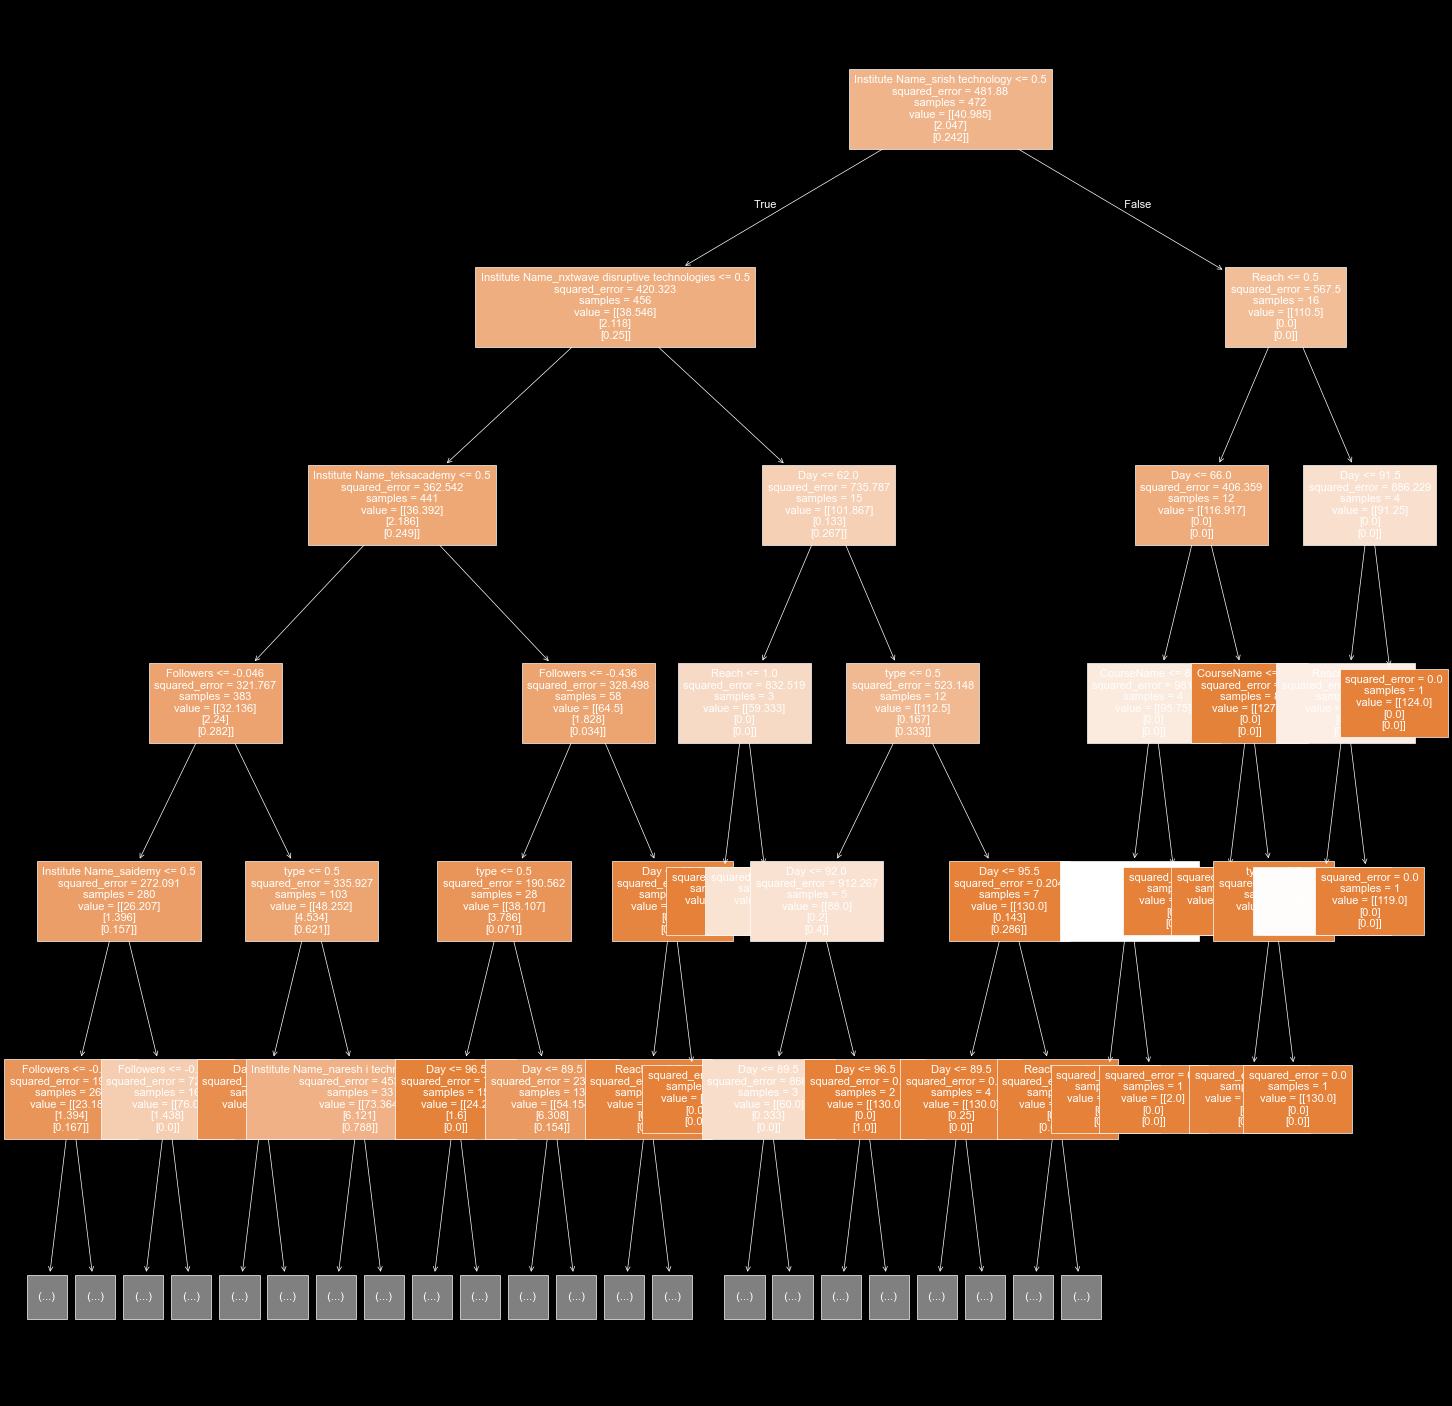

In [242]:
# Tree Visualization

from sklearn.tree import plot_tree

plt.figure(figsize=(18,18))
plot_tree(dtr,filled=True,fontsize=8,feature_names=list(xtrainr.columns),max_depth=5)
plt.show()

**4.4.7 Random Forest Regressor**

In [243]:
rfr.fit(xtrainr, ytrainr)

RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=50)

In [244]:
# Model Params

print("Model Params:")
print(rfr.get_params())
print()
print("Columns Importance:")
print()
for i, j in zip(rfr.feature_names_in_, rfr.feature_importances_):
    print(i+": "+str(round(j,2)))

Model Params:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}

Columns Importance:

CourseName: 0.12
Followers: 0.22
type: 0.08
Location: 0.0
Day: 0.06
Institute Name_besant technologies: 0.01
Institute Name_brolly academy: 0.0
Institute Name_cedlearn: 0.0
Institute Name_datamites: 0.01
Institute Name_elearn infotech: 0.01
Institute Name_excelr: 0.01
Institute Name_fita academy: 0.01
Institute Name_fullstackacademy: 0.01
Institute Name_harsha trainings: 0.01
Institute Name_innomatics research labs: 0.01
Institute Name_mindmajix: 0.02
Institute Name_naresh i technologies: 0.02
Institute Name_nxtwave disruptive technologies: 0.08
Institute Na

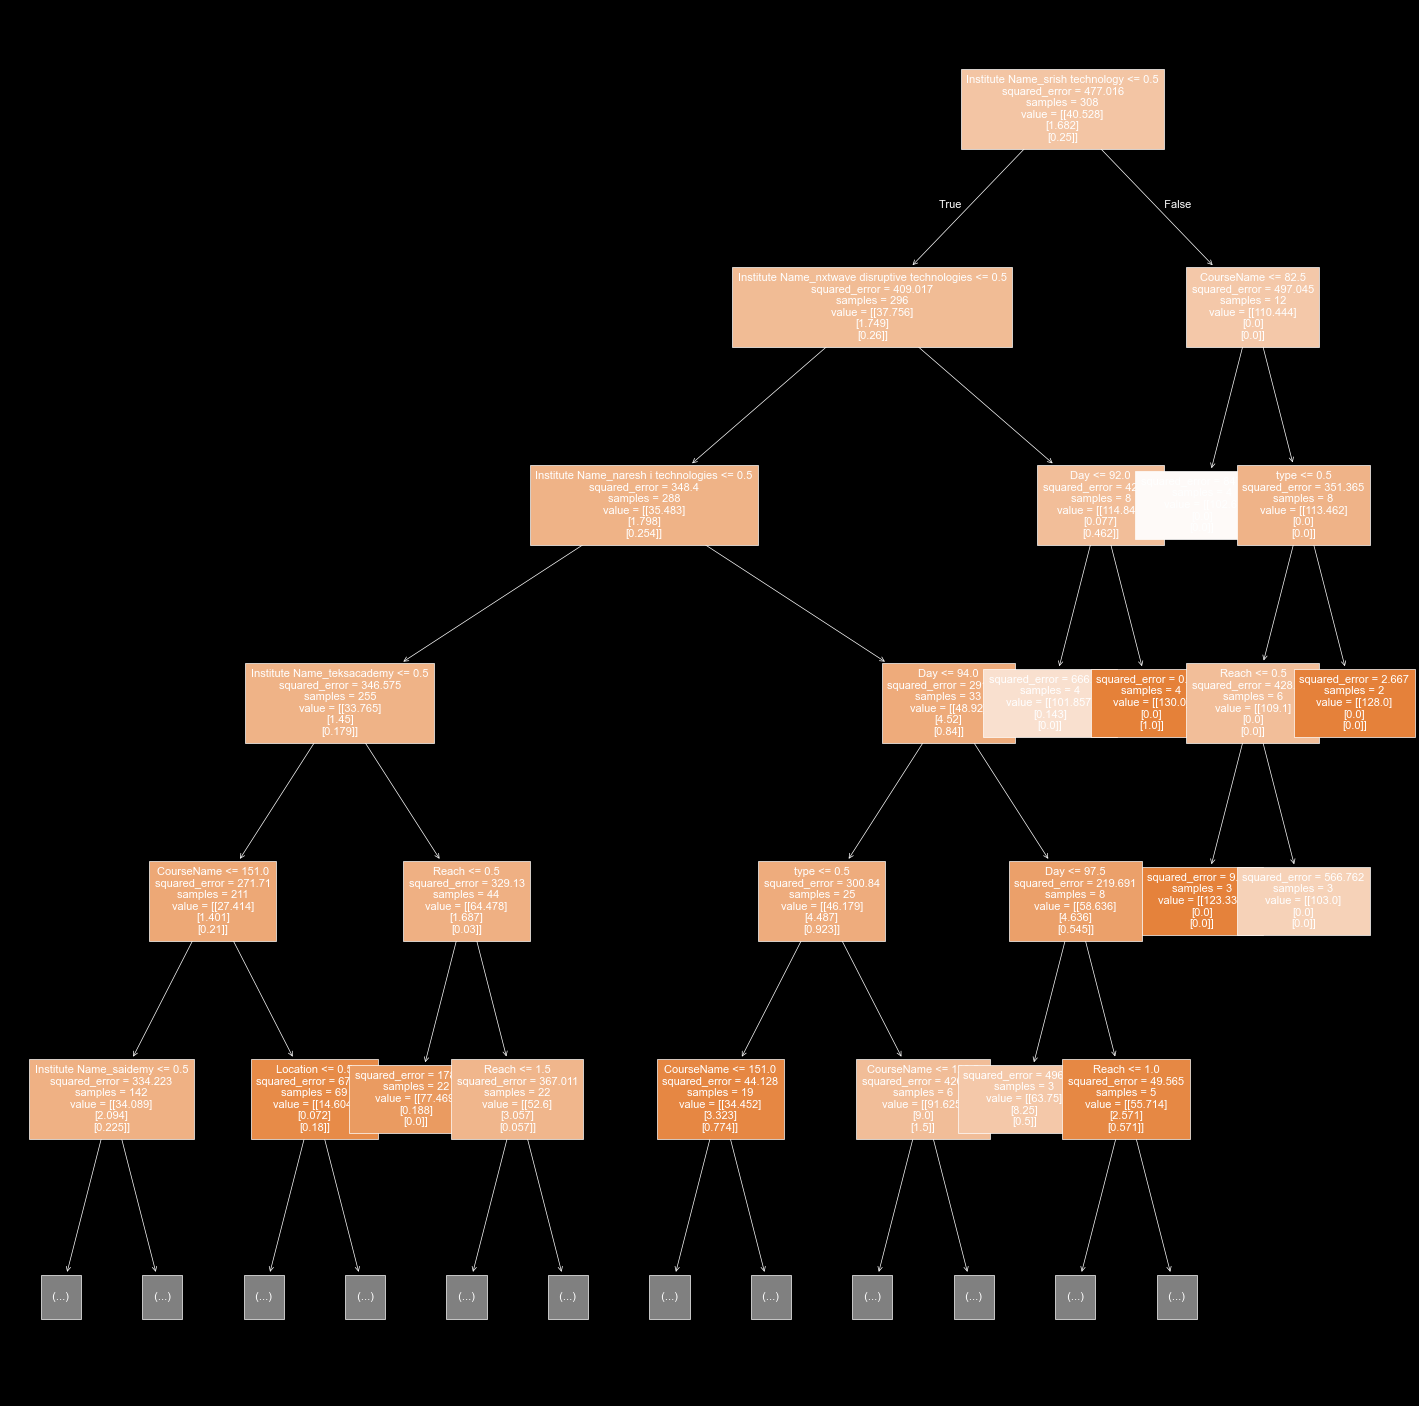

In [245]:
# One Tree Visualization

from sklearn.tree import plot_tree

plt.figure(figsize=(18,18))
plot_tree(rfr.estimators_[0],filled=True,fontsize=8,feature_names=list(xtrainr.columns),max_depth=5)
plt.show()

**4.4.8 Xgb Regressor**

In [246]:
# Model Training

xgbr.fit(xtrainr, ytrainr)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [247]:
xgbr.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.6,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': 0,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.01,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 500,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.6,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

****4.5 & 4.6 Predictions & Evaluations****

* Checking trained model performance with test data
* Using xtest data we will be getting predictions, these predictions will be compared to ytest
    - To compare we can use below metrics,
        - Loss Metric: **RMSE**
        - Score/Performance Metric: **R2Score**
* **For regression models , we have following to check model performance**

Technique | Outcome
-------|-----------
**Bias-Variance Trade Off**|Model Fitness Based on Train & Test Metrics
**Crossvalidation**|Checking Trained model performance on entire X and y data

In [248]:
# Libraries

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

* Looping through each trained model for test predictions, & evalaution

In [249]:
names = ['Multiple Linear Regression','Polynomial Regression','Lasso Regression','Ridge Regression',
         'Knn Regressor', 'Svm Regressor', 'Decision Tree Regressor', 'RandomForest Regressor', 'Xgboost Regressor']
models = {'mlr':mlr, 'poly':poly, 'lasso':lasso, 'ridge':ridge,  'knn':knnr, 'svm':svr, 'dt':dtr, 'rf':rfr, 'xgb':xgbr}

In [250]:
# Taking User-Defined Module

from mleval import regval

In [251]:
trainrmse, testrmse, trainr2, testr2, crossvalscore, fit = regval(xtrainr, xtrainr_poly, xtestr, xtestr_poly, ytrainr, ytestr, models)

In [252]:
# Complete Model Evaluation Table
# Display Options for Table
pd.set_option('display.float_format', lambda x: '%.3f' % x)

display(pd.DataFrame({'Model':names, 'TrainRMSE':trainrmse, 'TestRMSE':testrmse,
             'Trainscore':trainr2, 'Testscore':testr2, 'Crossvalscore':crossvalscore, 'Fit':fit}))

,Model,TrainRMSE,TestRMSE,Trainscore,Testscore,Crossvalscore,Fit
0,Multiple Linear Regression,14.970,14.270,0.380,0.330,0.300,Underfit
1,Polynomial Regression,10.920,117.360,0.610,-11.890,-7.810,Overfit
2,Lasso Regression,14.970,14.270,0.360,0.360,0.320,Underfit
3,Ridge Regression,15.000,14.270,0.380,0.340,0.310,Underfit
4,Knn Regressor,15.440,17.560,0.410,0.160,0.100,Underfit
5,Svm Regressor,22.950,20.640,-0.080,-0.050,-0.080,Underfit
6,Decision Tree Regressor,4.790,15.590,0.930,0.080,-0.040,Overfit
7,RandomForest Regressor,10.820,12.800,0.600,0.380,0.370,Overfit
8,Xgboost Regressor,9.860,12.220,0.650,0.380,0.380,Overfit


**4.7 Best Model**

In [253]:
# Taking output col distribution

Y.describe()

,Likes,Share,Comments
count,591.000,591.000,591.000
mean,40.550,1.993,0.240
std,37.286,3.647,0.651
min,1.000,0.000,0.000
25%,11.000,0.000,0.000
50%,29.000,0.000,0.000
75%,56.500,2.000,0.000
max,130.000,11.000,2.000


* By observing y col distribution it is clear that from the above table, test rmse values are very low for xgboost regressor
* According to above table , we can select Xgboost Regressor is better performance model for this data (low test rmse , high r2score, matching cross val score to test)

**4.8 Hyp Param Tuning**

**4.9 Saving Model**

* Saving Trained & Evaluated model for future predictions
    * From above training we need to save xgbr & ohe, sc objects
    * In python we have libraries , joblib, pickle to save model files

In [254]:
import joblib

# Saving trained model
joblib.dump(xgbr, 'xgbr.pkl')
# Saving onehot encoded model

joblib.dump(ohe, 'ohe.pkl')

joblib.dump(sc, "sc.pkl")
trained_feature_names = X.columns.tolist()
import pickle

with open("feature_names.pkl", "wb") as f:
    pickle.dump(trained_feature_names, f)


In [255]:
# Loading saved pickles and getting predictions

import joblib
xgbr= joblib.load('xgbr.pkl')
feature_names = xgbr.feature_names_in_.tolist()


sc = joblib.load("sc.pkl")

# Loading Saved object files
ohe = joblib.load('ohe.pkl')
   

# Loading Saved Ordinal Encoded files
with open('Day_encoding.pkl', 'rb') as f:
    Day_encoding = pickle.load(f)
    
with open('CourseName_encoding.pkl', 'rb') as f:
    CourseName_encoding = pickle.load(f)
with open("feature_names.pkl", "rb") as f:
    trained_feature_names = pickle.load(f)


In [256]:
import pandas as pd
import numpy as np

def LCSofSocialMedia_Post():
    print("Reference Data for Input:")
    
    # Load input data
    inpdata = pd.read_csv("inputdata1.csv")
    display(inpdata.head())

    print("\n Xgboost  regressor built on the below X columns:")
    print(inpdata.columns)

    print("\n======================= Enter User Input Data ====================")

    # User Inputs
    print("\nEnter Institute Name:")
    print(inpdata['Institute Name'].unique())
    insti = input("Select institute: ").strip()

    print("\nEnter Course Name:")
    print(inpdata['CourseName'].unique())
    course = input("Select course: ").strip()

    print("\nEnter Followers:")
    followers = eval(input(f"min-{inpdata['Followers'].min()}, max-{inpdata['Followers'].max()}: "))

    print("\nEnter type of post:")
    print(inpdata['type'].unique())
    typeofpost = input("Select type: ").strip()

    print("\nEnter Location:")
    print(inpdata['Location'].unique())
    location = input("Select location: ").strip()

    print("\nEnter Day:")
    print(inpdata['Day'].unique())
    day = input("Select day: ").strip()

    print("\nEnter Reach:")
    print(inpdata['Reach'].unique())
    reach = input("Select Reach: ").strip()

    # Create user input DataFrame
    row = pd.DataFrame([[insti, course, followers, typeofpost, location, day,reach]], columns=inpdata.columns)

    print("\nGiven User Input Data:")
    display(row)

    ####### Data Pre-Processing #######

    # Binary Encoding
    row['type'].replace({'post': 0, 'reel': 1}, inplace=True)
    row['Location'].replace({'hyderabad': 0, 'banglore': 1}, inplace=True)
    row['Reach'].replace({'low': 0, 'moderate': 1,'high':2}, inplace=True)

   # Ordinal Encoding
    row['Day'].replace(Day_encoding, inplace=True)
    row['CourseName'].replace(CourseName_encoding, inplace=True)
    
    
    # One-Hot Encoding
   
    if 'Institute Name' in row.columns:
        ohedata = ohe.transform(row[['Institute Name']]).toarray()
        ohedata = pd.DataFrame(ohedata, columns=ohe.get_feature_names_out())

    # Add missing columns if necessary
        missing_cols = set(trained_feature_names) - set(ohedata.columns)
        for col in missing_cols:
            ohedata[col] = 0  # Add missing columns with value 0

    # Ensure column order matches training
        ohedata = ohedata[trained_feature_names]

    # Merge with X
        X = pd.concat([row.drop(['Institute Name'], axis=1), ohedata], axis=1)
    else:
        raise KeyError("Column 'Institute Name' not found in DataFrame X. Available columns: ", row.columns)

    #Scaling
    row[['Followers']] = sc.transform(row[['Followers']])

    # Ensure feature alignment with the trained model
    expected_features = xgbr.feature_names_in_
    row = row.reindex(columns=feature_names, fill_value=0)

    print("\nProcessed features for prediction")
    print("********** Xgboost Regressor ***********")
    
    # Prediction
    try:
    # Predict Likes, Comments, and Shares
       predicted_values = xgbr.predict(row)[0]
    
       print("Likes:",round(predicted_values[0]),"Shares:",round(predicted_values[1]),"Comments:",round(predicted_values[2]))

    except Exception as e:
       print("\nError during prediction:", e)




In [257]:
 LCSofSocialMedia_Post()

Reference Data for Input:


,Institute Name,CourseName,Followers,type,Location,Day,Reach
0,quality thought,ai,10700.000,post,hyderabad,saturday,high
1,quality thought,ai,10700.000,post,hyderabad,friday,moderate
2,quality thought,ai,10700.000,post,hyderabad,thursday,low
3,quality thought,ai,10226.000,post,hyderabad,friday,moderate
4,besant technologies,ai,10700.000,post,hyderabad,tuesday,low



 Xgboost  regressor built on the below X columns:
Index(['Institute Name', 'CourseName', 'Followers', 'type', 'Location', 'Day',
       'Reach'],
      dtype='object')

======================= Enter User Input Data ====================

Enter Institute Name:
['quality thought' 'besant technologies' 'naresh i technologies'
 'innomatics research labs' 'fullstackacademy' 'saidemy' 'teksacademy'
 'datamites' 'cedlearn' 'elearn infotech'
 'nxtwave disruptive technologies' 'excelr' 'social prachar'
 'fita academy' 'mindmajix' 'brolly academy' 'prsoftwares'
 'harsha trainings' 'vcube software solutions' 'version it'
 'srish technology']
Select institute: excelr

Enter Course Name:
['ai' 'data analytics' 'gcp' 'data science' 'ds' 'dataskills'
 'full stack development' 'aws,devops' 'azure,devops']
Select course: gcp

Enter Followers:
min-4.0, max-54368.0: 2352

Enter type of post:
['post' 'reel']
Select type: post

Enter Location:
['hyderabad' 'banglore']
Select location: hyderabad

Enter Day:

,Institute Name,CourseName,Followers,type,Location,Day,Reach
0,excelr,gcp,2352,post,hyderabad,friday,low



Processed features for prediction
********** Xgboost Regressor ***********
Likes: 9 Shares: 0 Comments: 0
